In [247]:
pip install osmnx geopandas shapely


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [248]:
pip install --upgrade osmnx


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### 0.1 Notebook Setup (Imports & OSMnx Settings)
Importiere Geo-Libraries und setze OSMnx-Settings für reproduzierbare Overpass-Abfragen.

In [249]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point

pd.set_option("display.max_columns", None)
ox.settings.use_cache = False
ox.settings.log_console = True

In [250]:
import osmnx as ox
ox.__version__


'2.0.7'

### 1.2 OSM Extraction (OSM-first): Police Stations
Lade alle OSM-Features für Berlin mit amenity=police als Ausgangsbasis für das Emergency-Services-Dataset.

In [251]:


place = "Berlin, Germany"
tags_police = {"amenity": "police"}

gdf_police = ox.features_from_place(place, tags_police)

len(gdf_police)


64

In [252]:
gdf_police.head()


geometry addr:city addr:country  \
element id                                                            
node    29695282   POINT (13.35364 52.53366)    Berlin           DE   
        84644753   POINT (13.39057 52.50496)    Berlin           DE   
        206102770  POINT (13.34759 52.42769)       NaN          NaN   
        242769298  POINT (13.22691 52.52802)       NaN          NaN   
        244118624  POINT (13.43476 52.47916)    Berlin           DE   

                  addr:housenumber addr:postcode         addr:street  \
element id                                                             
node    29695282               61A         10559  Perleberger Straße   
        84644753               219         10969     Friedrichstraße   
        206102770              NaN           NaN                 NaN   
        242769298              NaN           NaN                 NaN   
        244118624                9         12053      Rollbergstraße   

                  addr:suburb amenity  check_date  \
element id                                          
node    29695282       Moabit  police  2024-06-14   
        84644753    Kreuzberg  police  2025-05-09   
        206102770         NaN  police         NaN   
        242769298         NaN  police         NaN   
        244118624         NaN  police         NaN   

                                          name wheelchair level  \
element id                                                        
node    29695282          Polizei Abschnitt 27    limited   NaN   
        84644753   Abschnitt 53 Kreuzberg-Nord         no   0;1   
        206102770         Polizei Abschnitt 46         no   NaN   
        242769298         Polizei Abschnitt 22        yes   NaN   
        244118624          Polizeiabschnitt 55    limited   NaN   

                                       name:de                      name:en  \
element id                                                                    
node    29695282                           NaN                          NaN   
        84644753   Abschnitt 53 Kreuzberg-Nord  District 53 North Kreuzberg   
        206102770                          NaN                          NaN   
        242769298                          NaN                          NaN   
        244118624                          NaN                          NaN   

                         operator operator:wikidata operator:wikipedia  \
element id                                                               
node    29695282              NaN               NaN                NaN   
        84644753   Polizei Berlin           Q328480  de:Polizei Berlin   
        206102770  Polizei Berlin           Q328480  de:Polizei Berlin   
        242769298             NaN               NaN                NaN   
        244118624             NaN               NaN                NaN   

                     wikidata                phone  \
element id                                           
node    29695282          NaN                  NaN   
        84644753   Q108875638                  NaN   
        206102770         NaN  +49 30 4664 446 701   
        242769298         NaN                  NaN   
        244118624  Q108875640                  NaN   

                                                             website  \
element id                                                             
node    29695282                                                 NaN   
        84644753                                                 NaN   
        206102770  https://www.berlin.de/polizei/dienststellen/la...   
        242769298                                                NaN   
        244118624                                                NaN   

                         contact:fax      contact:phone  \
element id                                                
node    29695282                 NaN                NaN   
        84644753                 NaN                NaN  

Police-POIs aus OSM geladen (Anzahl validieren). Nächster Schritt: Fire Stations und Ambulance Bases laden und anschließend Spalten/Geometrien vereinheitlichen.

In [253]:
gdf_police.columns


Index(['geometry', 'addr:city', 'addr:country', 'addr:housenumber',
       'addr:postcode', 'addr:street', 'addr:suburb', 'amenity', 'check_date',
       'name', 'wheelchair', 'level', 'name:de', 'name:en', 'operator',
       'operator:wikidata', 'operator:wikipedia', 'wikidata', 'phone',
       'website', 'contact:fax', 'contact:phone', 'contact:website',
       'building', 'short_name', 'url', 'wikipedia', 'note', 'police',
       'operator:short', 'name:ja', 'opening_hours', 'alt_name',
       'contact:email', 'start_date', 'access', 'surveillance',
       'building:levels', 'roof:shape', 'roof:levels', 'source', 'ref',
       'wheelchair:description', 'leaf_type', 'barrier', 'indoor',
       'description', 'heritage', 'heritage:operator', 'heritage:website',
       'ref:lda', 'wikimedia_commons', 'email', 'fax', 'room',
       'building:colour', 'camera:type', 'image', 'nohousenumber',
       'roof:colour', 'surveillance:type', 'surveillance:zone',
       'toilets:wheelchair', 'typ

In [254]:
gdf_police.geometry.type.value_counts()


Polygon         44
Point           19
MultiPolygon     1
Name: count, dtype: int64

### Geometry Normalization (OSM → Point Geometry)

OSM emergency service locations are returned with mixed geometry types (Points, Polygons, MultiPolygons).
For a unified POI dataset and reliable spatial joins, all geometries are normalized to Point representations.


In [255]:


# 1) Sicherstellen, dass wir in einem projected CRS sind (für korrekte Centroids!)
#    OSMNX liefert meist EPSG:4326 (Lat/Lon) -> für Centroid lieber auf Meter-Projektion
gdf = gdf_police.copy()

# Falls CRS fehlt, setze ihn (OSM ist i.d.R. WGS84)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

# Für Centroid-Berechnung in ein projected CRS (UTM Zone für Berlin: EPSG:32633)
gdf_proj = gdf.to_crs(epsg=32633)

# 2) Centroid für alles berechnen (Points bleiben praktisch gleich, Polygone werden Punkt)
gdf_proj["geometry_point"] = gdf_proj.geometry.centroid

# 3) Zurück zu EPSG:4326 und geometry ersetzen
gdf_out = gdf_proj.set_geometry("geometry_point").to_crs(epsg=4326).drop(columns=["geometry"])
gdf_out = gdf_out.rename(columns={"geometry_point": "geometry"}).set_geometry("geometry")

# Quick checks
print("Before:", gdf_police.geometry.geom_type.value_counts())
print("After:", gdf_out.geometry.geom_type.value_counts())


Before: Polygon         44
Point           19
MultiPolygon     1
Name: count, dtype: int64
After: Point    64
Name: count, dtype: int64


In [256]:
gdf_out["longitude"] = gdf_out.geometry.x
gdf_out["latitude"] = gdf_out.geometry.y

gdf_out[["latitude", "longitude"]].head()


latitude  longitude
element id                             
node    29695282   52.533663  13.353639
        84644753   52.504959  13.390570
        206102770  52.427692  13.347591
        242769298  52.528017  13.226911
        244118624  52.479156  13.434759

All geometries are now normalized to Point format and stored in EPSG:4326.
Latitude and longitude columns are extracted and ready for schema standardization and spatial enrichment (district/neighborhood mapping).


### Initial QA & Identifier Setup

Before merging multiple emergency service layers, basic quality checks and stable identifiers are created.
This includes duplicate detection on coordinate level, service metadata assignment, and generation of globally unique POI IDs.


In [257]:
# Duplikate auf Koordinatenbasis (grob)
dup_count = gdf_out.duplicated(subset=["latitude", "longitude"]).sum()
print("Duplicate lat/lon rows:", dup_count)


Duplicate lat/lon rows: 0


In [258]:
gdf_out["service_type"] = "police"
gdf_out["data_source"] = "osm"


In [259]:
element_prefix = {"node": 1, "way": 2, "relation": 3}

# element steht bei dir im Index-level "element"
prefix = gdf_out.index.get_level_values("element").map(element_prefix).astype("int64")
osm_id = gdf_out.index.get_level_values("id").astype("int64")

gdf_out["id"] = (prefix * 10**12 + osm_id).astype(str)  # als string speichern (DB: VARCHAR(20))


In [260]:
# Check: sind IDs unique?
gdf_out["id"].isna().sum(), gdf_out["id"].nunique(), len(gdf_out)

# Check: nur Zahlen?
gdf_out["id"].str.isnumeric().all()

# Kleiner Blick
gdf_out[["id", "service_type", "data_source"]].head()


id service_type data_source
element id                                               
node    29695282   1000029695282       police         osm
        84644753   1000084644753       police         osm
        206102770  1000206102770       police         osm
        242769298  1000242769298       police         osm
        244118624  1000244118624       police         osm

 All POIs have unique, numeric, non-null identifiers.
Service type and data source are assigned and ready for schema standardization and cross-source integration.


### Schema Standardization (Mandatory POI Fields)

Map OSM attributes to the unified emergency services schema.
This step prepares consistent columns for name, address, operator, contact information, and accessibility features.


In [261]:
# 1) Basisspalten mappen/erzeugen
gdf_out["name"] = gdf_out.get("name").fillna("Unknown")

gdf_out["street"] = gdf_out.get("addr:street")
gdf_out["house_number"] = gdf_out.get("addr:housenumber")
gdf_out["postal_code"] = gdf_out.get("addr:postcode")

# 2) address zusammenbauen (einfach + robust)
gdf_out["address"] = (
    gdf_out[["street", "house_number", "postal_code"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
gdf_out.loc[gdf_out["address"] == "", "address"] = None

# 3) operating_hours
gdf_out["operating_hours"] = gdf_out.get("opening_hours")

# 4) operator
gdf_out["operator"] = gdf_out.get("operator")

# 5) contact_info: zusammensammeln (wenn vorhanden)
contact_cols = ["phone", "contact:phone", "email", "contact:email", "website", "contact:website"]
existing = [c for c in contact_cols if c in gdf_out.columns]

def build_contact(row):
    parts = []
    for c in existing:
        v = row.get(c)
        if v is not None and str(v) != "nan" and str(v).strip() != "":
            parts.append(f"{c}={v}")
    return "; ".join(parts) if parts else None

gdf_out["contact_info"] = gdf_out.apply(build_contact, axis=1)

# 6) accessibility_features (z.B. wheelchair)
gdf_out["accessibility_features"] = gdf_out.get("wheelchair")


 Core schema fields are standardized and populated where available.
The dataset is now ready for spatial enrichment (district and neighborhood mapping).


### Unified POI Schema Projection

Select and order the mandatory columns for the emergency services POI schema.
This step creates a clean, consistent dataset aligned with the final database structure.


In [262]:
unified_cols = [
    "id",
    "name",
    "latitude",
    "longitude",
    "geometry",
    "service_type",
    "operator",
    "address",
    "street",
    "house_number",
    "postal_code",
    "contact_info",
    "operating_hours",
    "accessibility_features",
    "data_source",
]

gdf_unified_police = gdf_out[unified_cols].copy()

gdf_unified_police.head()


id                         name   latitude  \
element id                                                                 
node    29695282   1000029695282         Polizei Abschnitt 27  52.533663   
        84644753   1000084644753  Abschnitt 53 Kreuzberg-Nord  52.504959   
        206102770  1000206102770         Polizei Abschnitt 46  52.427692   
        242769298  1000242769298         Polizei Abschnitt 22  52.528017   
        244118624  1000244118624          Polizeiabschnitt 55  52.479156   

                   longitude                   geometry service_type  \
element id                                                             
node    29695282   13.353639  POINT (13.35364 52.53366)       police   
        84644753   13.390570  POINT (13.39057 52.50496)       police   
        206102770  13.347591  POINT (13.34759 52.42769)       police   
        242769298  13.226911  POINT (13.22691 52.52802)       police   
        244118624  13.434759  POINT (13.43476 52.47916)       police   

                         operator                       address  \
element id                                                        
node    29695282              NaN  Perleberger Straße 61A 10559   
        84644753   Polizei Berlin     Friedrichstraße 219 10969   
        206102770  Polizei Berlin                          None   
        242769298             NaN                          None   
        244118624             NaN        Rollbergstraße 9 12053   

                               street house_number postal_code  \
element id                                                       
node    29695282   Perleberger Straße          61A       10559   
        84644753      Friedrichstraße          219       10969   
        206102770                 NaN          NaN         NaN   
        242769298                 NaN          NaN         NaN   
        244118624      Rollbergstraße            9       12053   

                                                        contact_info  \
element id                                                             
node    29695282                                                None   
        84644753                                                None   
        206102770  phone=+49 30 4664 446 701; website=https://www...   
        242769298                                               None   
        244118624  contact:phone=+49 30 4664555700; contact:websi...   

                  operating_hours accessibility_features data_source  
element id                                                            
node    29695282              NaN                limited         osm  
        84644753              NaN                     no         osm  
        206102770             NaN                     no         osm  
        242769298             NaN                    yes         osm  
        244118624             NaN                limited         osm

In [263]:
gdf_unified_police = gdf_unified_police.reset_index(drop=True)
gdf_unified_police.head()


,id,name,latitude,longitude,geometry,service_type,operator,address,street,house_number,postal_code,contact_info,operating_hours,accessibility_features,data_source
0,1000029695282,Polizei Abschnitt 27,52.533663,13.353639,POINT (13.35364 52.53366),police,NaN,Perleberger Straße 61A 10559,Perleberger Straße,61A,10559,None,NaN,limited,osm
1,1000084644753,Abschnitt 53 Kreuzberg-Nord,52.504959,13.390570,POINT (13.39057 52.50496),police,Polizei Berlin,Friedrichstraße 219 10969,Friedrichstraße,219,10969,None,NaN,no,osm
2,1000206102770,Polizei Abschnitt 46,52.427692,13.347591,POINT (13.34759 52.42769),police,Polizei Berlin,None,NaN,NaN,NaN,phone=+49 30 4664 446 701; website=https://www...,NaN,no,osm
3,1000242769298,Polizei Abschnitt 22,52.528017,13.226911,POINT (13.22691 52.52802),police,NaN,None,NaN,NaN,NaN,None,NaN,yes,osm
4,1000244118624,Polizeiabschnitt 55,52.479156,13.434759,POINT (13.43476 52.47916),police,NaN,Rollbergstraße 9 12053,Rollbergstraße,9,12053,contact:phone=+49 30 4664555700; contact:websi...,NaN,limited,osm


 The police POI dataset now follows the unified schema with a flat index.
Each row represents one emergency service location and is ready for enrichment.


### Data Completeness Check

Assess data availability for key schema fields to identify gaps and justify optional enrichment from external sources.


In [264]:
cols = ["operator","address","contact_info","operating_hours","accessibility_features","name"]
missing_pct = (gdf_unified_police[cols].isna().mean()*100).round(1).sort_values(ascending=False)
missing_pct


operating_hours           92.2
operator                  46.9
contact_info              39.1
accessibility_features    39.1
address                   37.5
name                       0.0
dtype: float64

Several optional fields (e.g. operating hours, operator, contact info) show limited coverage in OSM.
These gaps are expected and can be supplemented from Berlin Open Data or Wikidata where required.


In [265]:
gdf_unified_police.columns


Index(['id', 'name', 'latitude', 'longitude', 'geometry', 'service_type',
       'operator', 'address', 'street', 'house_number', 'postal_code',
       'contact_info', 'operating_hours', 'accessibility_features',
       'data_source'],
      dtype='object')

In [266]:
import numpy as np

gdf_unified_police["operator"] = (
    gdf_unified_police["operator"]
    .replace("", np.nan)
)


In [267]:
gdf_unified_police["operator"] = gdf_unified_police["operator"].replace("None", np.nan)


### Operator Field Assessment (OSM-first)

Evaluate the availability and consistency of the `operator` field for police stations.
Only normalization of existing OSM values is applied; missing operators are not filled from external sources in accordance with the OSM-first principle.


In [268]:
gdf_unified_police["operator"].isna().mean().round(3)
gdf_unified_police["operator"].value_counts(dropna=False).head(10)


operator
NaN                  30
Polizei Berlin       25
Bundespolizei         7
Bundeskriminalamt     2
Name: count, dtype: int64

 The operator field shows heterogeneous coverage across Berlin police stations.
Roughly half of the locations lack operator information in OSM, while existing values mainly reference federal and state-level police authorities.


In [269]:
operator_map = {
    "Polizei Berlin": "polizei_berlin",
    "Bundespolizei": "bundespolizei",
    "Bundeskriminalamt": "bundeskriminalamt"
}

gdf_unified_police["operator_clean"] = (
    gdf_unified_police["operator"]
    .map(operator_map)
)


### Operator Field Cleanup

Normalize empty and placeholder values to NaN to ensure consistent missing value handling before analysis and enrichment.


In [270]:
gdf_unified_police["operator_clean"].value_counts(dropna=False)


operator_clean
NaN                  30
polizei_berlin       25
bundespolizei         7
bundeskriminalamt     2
Name: count, dtype: int64

### Contact Information Field Exploration

Inspect available OSM contact-related tags to determine how phone, email, and website information can be consolidated into a unified contact field.


In [271]:
# 1) Welche Contact-Felder existieren?
contact_candidates = [
    "phone", "contact:phone",
    "website", "contact:website",
    "email", "contact:email",
    "fax", "contact:fax",
]

available = [c for c in contact_candidates if c in gdf_out.columns]
available


['phone',
 'contact:phone',
 'website',
 'contact:website',
 'email',
 'contact:email',
 'fax',
 'contact:fax']

### Contact Info Consolidation (OSM Tags → Unified Field)

OSM stores contact details in multiple tag namespaces (e.g., `contact:phone` vs `phone`).
Here we consolidate these fields into a single `contact_info` column for the unified schema.


In [272]:
import pandas as pd

def pick_first_nonnull(df, cols):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.Series([pd.NA] * len(df), index=df.index)
    out = df[cols[0]]
    for c in cols[1:]:
        out = out.fillna(df[c])
    return out

# 2) Feldweise konsolidieren
gdf_out["phone_clean"]   = pick_first_nonnull(gdf_out, ["contact:phone", "phone"])
gdf_out["website_clean"] = pick_first_nonnull(gdf_out, ["contact:website", "website"])
gdf_out["email_clean"]   = pick_first_nonnull(gdf_out, ["contact:email", "email"])
gdf_out["fax_clean"]     = pick_first_nonnull(gdf_out, ["contact:fax", "fax"])


In [273]:
def build_contact_info(row):
    parts = []
    if pd.notna(row.get("phone_clean")):
        parts.append(f"phone={row['phone_clean']}")
    if pd.notna(row.get("website_clean")):
        parts.append(f"website={row['website_clean']}")
    if pd.notna(row.get("email_clean")):
        parts.append(f"email={row['email_clean']}")
    if pd.notna(row.get("fax_clean")):
        parts.append(f"fax={row['fax_clean']}")
    return "; ".join(parts) if parts else pd.NA

gdf_out["contact_info"] = gdf_out.apply(build_contact_info, axis=1)

# Quick QA
gdf_out["contact_info"].isna().mean().round(3), gdf_out["contact_info"].dropna().head(5)


(np.float64(0.391),
 element  id       
 node     206102770    phone=+49 30 4664 446 701; website=https://www...
          244118624    phone=+49 30 4664555700; website=https://www.b...
          614482788    phone=+49 30 4664332700; website=https://www.b...
          659031944    website=http://www.berlin.de/polizei/bezirk/di...
          988558167                              phone=+49 30 4664334700
 Name: contact_info, dtype: object)

 Contact details have been consolidated into `contact_info`.
A quick QA check verifies coverage (missing share) and shows sample non-null values for validation.


In [274]:
print("unified index names:", gdf_unified_police.index.names)
print("out index names:", gdf_out.index.names)


unified index names: [None]
out index names: ['element', 'id']


In [275]:
print("id in gdf_out columns?", "id" in gdf_out.columns)


id in gdf_out columns? True


In [276]:
gdf_unified_police["id"].duplicated().sum()


np.int64(0)

### Propagate Contact Info to Unified Dataset

The unified police dataset was created earlier, so we merge the newly built `contact_info` back in using the stable `id` key.


In [277]:
# 1) Index-Level entfernen, damit 'id' nur noch eine normale Spalte ist
left  = gdf_unified_police.reset_index(drop=True)
right = gdf_out.reset_index(drop=True)[["id", "contact_info"]]

# 2) Falls left schon contact_info hat, erst entfernen (optional, aber sauber)
left = left.drop(columns=["contact_info"], errors="ignore")

# 3) Merge
gdf_unified_police = left.merge(
    right,
    on="id",
    how="left",
    validate="one_to_one"   # optional, aber gut fürs Debugging
)

gdf_unified_police[["name", "contact_info"]].head(10)


,name,contact_info
0,Polizei Abschnitt 27,<NA>
1,Abschnitt 53 Kreuzberg-Nord,<NA>
2,Polizei Abschnitt 46,phone=+49 30 4664 446 701; website=https://www...
3,Polizei Abschnitt 22,<NA>
4,Polizeiabschnitt 55,phone=+49 30 4664555700; website=https://www.b...
5,Gemeinsames Terrorismusabwehrzentrum,<NA>
6,Bundespolizei,<NA>
7,Stadionwache,<NA>
8,Polizei Berlin – Abschnitt 57,phone=+49 30 4664332700; website=https://www.b...
9,Polizei Berlin Abschnitt 16,website=http://www.berlin.de/polizei/bezirk/di...


In [278]:
print("dups in right id:", right["id"].duplicated().sum())
print("dups in left id:", gdf_unified_police["id"].duplicated().sum())


dups in right id: 0
dups in left id: 0


 Merge completed successfully with one-to-one validation and no duplicated IDs.
The unified dataset now contains the standardized `contact_info` field.


In [279]:
gdf.duplicated(subset=["name"])


element  id        
node     29695282      False
         84644753      False
         206102770     False
         242769298     False
         244118624     False
                       ...  
way      1051488422    False
         1087550511     True
         1137216638    False
         1158500479    False
         1424485231    False
Length: 64, dtype: bool

### Name Duplicate Exploration (QA)

Inspect repeated `name` values to understand potential duplicates. Note: name alone is not a reliable deduplication key for emergency service locations.


In [280]:
gdf_unified_police.columns = (
    gdf_unified_police.columns
    .str.lower()
    .str.replace(":", "_")
)


In [281]:
gdf = gdf_unified_police.copy()

# (A) Exakte Dubletten nach Name (nur falls name vorhanden)
dup_name_mask = gdf["name"].notna() & gdf.duplicated(subset=["name"], keep="first")
print("Duplicate names:", dup_name_mask.sum())

# optional entfernen:
gdf = gdf[~dup_name_mask].copy()

Duplicate names: 6


Duplicate names are expected (e.g., standardized station naming). No rows are removed based on name alone; deduplication should consider spatial proximity and additional attributes.


### Approximate Proximity Duplicate Check (≤10m)

Check for very close-by points that may represent duplicate POIs. This is a lightweight heuristic and primarily used for reporting; final deduplication is applied during cross-source integration.


In [282]:
# (B) Distanz-Dedupe (5–10m): gleiche/nahe Punkte clustern
gdf_m = gdf.to_crs(epsg=32633)

# Koordinaten holen
coords = np.vstack([gdf_m.geometry.x.values, gdf_m.geometry.y.values]).T

# Sehr einfache "close duplicate"-Heuristik:
# sortiere nach x,y und vergleiche nur Nachbarn (schnell, reicht meist)
order = np.lexsort((coords[:,1], coords[:,0]))
gdf_m = gdf_m.iloc[order].copy()
coords = coords[order]

threshold = 10  # meters (du kannst auch 5 testen)
keep = np.ones(len(gdf_m), dtype=bool)

for i in range(1, len(gdf_m)):
    dx = coords[i,0] - coords[i-1,0]
    dy = coords[i,1] - coords[i-1,1]
    if (dx*dx + dy*dy) <= threshold**2:
        # wenn sehr nah: drop den späteren
        keep[i] = False

print("Close duplicates (<=10m):", (~keep).sum())
gdf_m = gdf_m[keep].copy()

# zurück zu WGS84
gdf_unified_police_clean = gdf_m.to_crs(epsg=4326)
gdf_unified_police_clean.head()


Close duplicates (<=10m): 0


,id,name,latitude,longitude,geometry,service_type,operator,address,street,house_number,postal_code,operating_hours,accessibility_features,data_source,operator_clean,contact_info
54,2000727014524,Polizeiabschnitt 23,52.522162,13.187871,POINT (13.18787 52.52216),police,NaN,Schmidt-Knobelsdorf-Straße 27 13581,Schmidt-Knobelsdorf-Straße,27,13581,NaN,limited,osm,NaN,website=https://www.berlin.de/polizei/dienstst...
55,2000727646449,Polizei Abschnitt 43,52.431533,13.195114,POINT (13.19511 52.43153),police,NaN,Alemannenstraße 10 14129,Alemannenstraße,10,14129,NaN,yes,osm,NaN,phone=+49 30 4664443701; website=https://www.b...
44,2000380533978,Polizei Abschnitt 21,52.539403,13.200059,POINT (13.20006 52.5394),police,NaN,Moritzstraße 10 13597,Moritzstraße,10,13597,NaN,yes,osm,NaN,phone=+49 30 4664221700; website=http://www.be...
21,2000005095457,Polizeidirektion 2 / Polizeiakademie,52.527094,13.226783,POINT (13.22678 52.52709),police,NaN,None,NaN,NaN,NaN,Mo-Th 07:00-15:30; Fr 07:00-15:00,NaN,osm,NaN,website=https://www.berlin.de/polizei/dienstst...
3,1000242769298,Polizei Abschnitt 22,52.528017,13.226911,POINT (13.22691 52.52802),police,NaN,None,NaN,NaN,NaN,NaN,yes,osm,NaN,<NA>


Proximity check completed. Close-duplicate count is logged for QA; records are not removed unless a clear deduplication rule is applied.


### Geospatial QA Checks

Validate coordinate completeness and perform a quick sanity check to ensure all POIs fall within a rough Berlin bounding box.


In [283]:
# fehlende lat/lon prüfen
missing_latlon = gdf_unified_police_clean["latitude"].isna() | gdf_unified_police_clean["longitude"].isna()
print("Missing lat/lon:", missing_latlon.sum())

# innerhalb grober Berlin-Bounds (quick sanity check)
lat_ok = gdf_unified_police_clean["latitude"].between(52.3, 52.7)
lon_ok = gdf_unified_police_clean["longitude"].between(13.0, 13.8)
out_of_bounds = ~(lat_ok & lon_ok)
print("Out of bounds (rough Berlin bbox):", out_of_bounds.sum())


Missing lat/lon: 0
Out of bounds (rough Berlin bbox): 0


All POIs have valid coordinates and fall within the expected Berlin extent (rough bounding box check).


## Fire & Ambulance (OSM Extraction)

Fetch Berlin emergency service locations from OpenStreetMap using OSMnx.
OSM is treated as the authoritative primary source (OSM-first).


In [284]:
place = "Berlin, Germany"

gdf_fire = ox.features_from_place(place, {"amenity": "fire_station"})
gdf_ambulance = ox.features_from_place(place, {"emergency": "ambulance_station"})

print(len(gdf_fire), len(gdf_ambulance))


100 30


Retrieved raw OSM features for fire stations and ambulance bases. Next: normalize geometry to Points and extract lat/lon for a consistent POI dataset.


### Geometry Normalization (Mixed OSM geometries → Point)

OSM returns mixed geometry types (Point/Polygon/MultiPolygon).  
For the unified POI schema we standardize all rows to Point geometry (centroids for polygons).


In [285]:
import geopandas as gpd

def normalize_to_points(gdf_raw: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf_raw.copy()

    # CRS sicherstellen
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)

    # Für saubere Centroids in Meter-Projektion
    gdf_m = gdf.to_crs(epsg=32633)
    gdf_m["geometry_point"] = gdf_m.geometry.centroid

    # zurück zu WGS84 und geometry ersetzen
    gdf_out = (
        gdf_m.set_geometry("geometry_point")
            .to_crs(epsg=4326)
            .drop(columns=["geometry"], errors="ignore")
            .rename(columns={"geometry_point": "geometry"})
    )
    gdf_out = gdf_out.set_geometry("geometry")

    # lat/lon
    gdf_out["longitude"] = gdf_out.geometry.x
    gdf_out["latitude"]  = gdf_out.geometry.y

    return gdf_out

gdf_fire_out = normalize_to_points(gdf_fire)
gdf_ambulance_out = normalize_to_points(gdf_ambulance)

print("Fire geom types:", gdf_fire_out.geometry.geom_type.value_counts().to_dict())
print("Amb  geom types:", gdf_ambulance_out.geometry.geom_type.value_counts().to_dict())


Fire geom types: {'Point': 100}
Amb  geom types: {'Point': 30}


 Geometry normalization complete: all features are Points in EPSG:4326, with `latitude` and `longitude` extracted from the geometry.


### Source Metadata & Stable IDs

Add `service_type` and `data_source` for provenance, and generate a stable OSM-based primary key (`id`) from the OSM element type and OSM ID.


In [286]:
gdf_fire_out["service_type"] = "fire"
gdf_fire_out["data_source"] = "osm"

gdf_ambulance_out["service_type"] = "ambulance"
gdf_ambulance_out["data_source"] = "osm"


In [287]:
def build_osm_id(gdf_out: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    element_prefix = {"node": 1, "way": 2, "relation": 3}

    prefix = gdf_out.index.get_level_values("element").map(element_prefix).astype("int64")
    osm_id = gdf_out.index.get_level_values("id").astype("int64")

    gdf_out = gdf_out.copy()
    gdf_out["id"] = (prefix * 10**12 + osm_id).astype(str)
    return gdf_out

gdf_fire_out = build_osm_id(gdf_fire_out)
gdf_ambulance_out = build_osm_id(gdf_ambulance_out)


In [288]:
unified_cols = [
    "id",
    "name",
    "latitude",
    "longitude",
    "geometry",
    "service_type",
    "operator",
    "address",
    "street",
    "house_number",
    "postal_code",
    "contact_info",
    "operating_hours",
    "accessibility_features",
    "data_source",
]

def select_unified(gdf_out: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    g = gdf_out.copy()

   
    for col in ["operator","address","street","house_number","postal_code","contact_info","operating_hours","accessibility_features"]:
        if col not in g.columns:
            g[col] = None

    if "name" not in g.columns:
        g["name"] = "Unknown"

    return g[unified_cols].copy()

gdf_unified_fire = select_unified(gdf_fire_out)
gdf_unified_ambulance = select_unified(gdf_ambulance_out)

gdf_unified_fire.head()


id                                 name  \
element id                                                              
node    98896966   1000098896966         Berufsfeuerwache Wilmersdorf   
        253618460  1000253618460      Berufsfeuerwache Friedrichshain   
        270905719  1000270905719  Freiwillige Feuerwehr Wilhelmshagen   
        330880463  1000330880463          Freiwillige Feuerwehr Mitte   
        332614340  1000332614340       Freiwillige Feuerwehr Tegelort   

                    latitude  longitude                   geometry  \
element id                                                           
node    98896966   52.487454  13.320688  POINT (13.32069 52.48745)   
        253618460  52.511829  13.444549  POINT (13.44455 52.51183)   
        270905719  52.436717  13.716157  POINT (13.71616 52.43672)   
        330880463  52.526553  13.389200   POINT (13.3892 52.52655)   
        332614340  52.570748  13.228902   POINT (13.2289 52.57075)   

                  service_type            operator address street  \
element id                                                          
node    98896966          fire  Berliner Feuerwehr    None   None   
        253618460         fire  Berliner Feuerwehr    None   None   
        270905719         fire                 NaN    None   None   
        330880463         fire  Berliner Feuerwehr    None   None   
        332614340         fire                 NaN    None   None   

                  house_number postal_code contact_info operating_hours  \
element id                                                                
node    98896966          None        None         None            None   
        253618460         None        None         None            None   
        270905719         None        None         None            None   
        330880463         None        None         None            None   
        332614340         None        None         None            None   

                  accessibility_features data_source  
element id                                            
node    98896966                    None         osm  
        253618460                   None         osm  
        270905719                   None         osm  
        330880463                   None         osm  
        332614340                   None         osm

### Source Metadata & Stable IDs

Add `service_type` and `data_source` for provenance, and generate a stable OSM-based primary key (`id`) from the OSM element type and OSM ID.


In [289]:
gdf_fire_out = build_osm_id(gdf_fire_out)

# Quick check
print("duplicate ids:", gdf_fire_out["id"].duplicated().sum())


duplicate ids: 0


 IDs generated successfully. The dataset is now ready for unified schema selection and later concatenation across services.


### Unified Schema Projection

Select and standardize columns according to the mandatory POI schema for the MVP.
Missing fields are kept as nulls to be optionally enriched later (OSM-first).


In [290]:
gdf_unified_fire = select_unified(gdf_fire_out)

gdf_unified_fire.head()
gdf_unified_fire.columns


Index(['id', 'name', 'latitude', 'longitude', 'geometry', 'service_type',
       'operator', 'address', 'street', 'house_number', 'postal_code',
       'contact_info', 'operating_hours', 'accessibility_features',
       'data_source'],
      dtype='object')

 Unified schema applied for Fire and Ambulance. Next: apply the same pipeline to other services and perform spatial enrichment (district/neighborhood mapping).


In [291]:
# Missing lat/lon?
missing_latlon = gdf_unified_fire["latitude"].isna().sum() + gdf_unified_fire["longitude"].isna().sum()
print("missing lat/lon (total):", missing_latlon)

# Optional: Rows mit fehlender Koordinate anzeigen
gdf_unified_fire[gdf_unified_fire["latitude"].isna() | gdf_unified_fire["longitude"].isna()].head()


missing lat/lon (total): 0


,,id,name,latitude,longitude,geometry,service_type,operator,address,street,house_number,postal_code,contact_info,operating_hours,accessibility_features,data_source
element,id,,,,,,,,,,,,,,,


### Operator field assessment (Fire)

The `operator` field for fire stations shows high consistency in OSM.
Where present, the value is almost exclusively `Berliner Feuerwehr`.
Missing values mainly affect volunteer fire stations and do not indicate alternative operators.
In accordance with the OSM-first principle, no enrichment or inference is applied.


In [292]:
display(
    gdf_unified_fire.loc[gdf_unified_fire["operator"].notna(),
                         ["name", "operator", "street", "postal_code", "data_source"]]
    .head(15)
)


name  \
element  id                                                   
node     98896966              Berufsfeuerwache Wilmersdorf   
         253618460          Berufsfeuerwache Friedrichshain   
         330880463              Freiwillige Feuerwehr Mitte   
         343472804              Berufsfeuerwache Karlshorst   
         3354419269                  Berufsfeuerwache Ranke   
         4706714959          Freiwillige Feuerwehr Biesdorf   
         5764101264                  Berufsfeuerwache Urban   
relation 16765216         Feuer- und Rettungswache Steglitz   
way      25492717              Berufsfeuerwache Marienfelde   
         30627912         FW Charlottenburg- Nord (BF 3600)   
         30627921          Technischer Dienst I (TD 1 3639)   
         30628046                    Berufsfeuerwache Tegel   
         43722263    Freiwillige Feuerwehr Hohenschönhausen   
         49895351         Freiwillige Feuerwehr Lichtenrade   
         51906459           Dienstgelände Nikolaus-Groß-Weg   

                               operator street postal_code data_source  
element  id                                                             
node     98896966    Berliner Feuerwehr   None        None         osm  
         253618460   Berliner Feuerwehr   None        None         osm  
         330880463   Berliner Feuerwehr   None        None         osm  
         343472804   Berliner Feuerwehr   None        None         osm  
         3354419269  Berliner Feuerwehr   None        None         osm  
         4706714959  Berliner Feuerwehr   None        None         osm  
         5764101264  Berliner Feuerwehr   None        None         osm  
relation 16765216    Berliner Feuerwehr   None        None         osm  
way      25492717    Berliner Feuerwehr   None        None         osm  
         30627912    Berliner Feuerwehr   None        None         osm  
         30627921    Berliner Feuerwehr   None        None         osm  
         30628046    Berliner Feuerwehr   None        None         osm  
         43722263    Berliner Feuerwehr   None        None         osm  
         49895351    Berliner Feuerwehr   None        None         osm  
         51906459    Berliner Feuerwehr   None        None         osm

In [293]:
display(
    gdf_unified_fire.loc[gdf_unified_fire["operator"].isna(),
                         ["name", "street", "postal_code", "data_source"]]
    .head(15)
)


name street postal_code  \
element id                                                                     
node    270905719     Freiwillige Feuerwehr Wilhelmshagen   None        None   
        332614340          Freiwillige Feuerwehr Tegelort   None        None   
        339387524             Freiwillige Feuerwehr Karow   None        None   
        450174418        Freiwillige Feuerwehr Karlshorst   None        None   
        577355077                                     NaN   None        None   
        674086104      Freiwillige Feuerwehr Spandau-Nord   None        None   
        944868560                                     GZS   None        None   
        4314579068         Freiwillige Feuerwehr Neukölln   None        None   
        5764101263            Freiwillige Feuerwehr Urban   None        None   
        6621423513         Freiwillige Feuerwehr Wittenau   None        None   
        6621423514      Freiwillige Feuerwehr Marienfelde   None        None   
        6621423515            Freiwillige Feuerwehr Tegel   None        None   
        6621423516           Freiwillige Feuerwehr Suarez   None        None   
        6621423517   Freiwillige Feuerwehr Friedrichshain   None        None   
        10039426205       Freiwillige Feuerwehr Weißensee   None        None   

                    data_source  
element id                       
node    270905719           osm  
        332614340           osm  
        339387524           osm  
        450174418           osm  
        577355077           osm  
        674086104           osm  
        944868560           osm  
        4314579068          osm  
        5764101263          osm  
        6621423513          osm  
        6621423514          osm  
        6621423515          osm  
        6621423516          osm  
        6621423517          osm  
        10039426205         osm

Conclusion:  
The operator field for fire stations is sufficiently consistent for the MVP.
Missing values are accepted as-is and documented as an OSM coverage limitation.


In [294]:
import geopandas as gpd
import pandas as pd

def dedupe_by_name_or_distance(gdf: gpd.GeoDataFrame, max_dist_m: float = 10.0) -> gpd.GeoDataFrame:
    g = gdf.copy()

    # 1) Name-normalisierung (für "identische Namen")
    name_norm = (
        g["name"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    g["_name_norm"] = name_norm

    # 2) In Meter-CRS projizieren für Distanzchecks
    g_m = g.to_crs(epsg=32633).copy()
    g_m["_row"] = range(len(g_m))

    # 3) Self nearest-join (innerhalb max_dist_m)
    pairs = gpd.sjoin_nearest(
        g_m[["_row", "_name_norm", "geometry"]],
        g_m[["_row", "_name_norm", "geometry"]],
        how="inner",
        max_distance=max_dist_m,
        distance_col="_dist",
    )

    # 4) Nur echte Paare (nicht mit sich selbst) und ohne doppelte Richtung
    pairs = pairs[pairs["_row_left"] < pairs["_row_right"]].copy()

    # 5) Duplikat-Regel: gleicher Name ODER Distanz <= max_dist_m
    pairs = pairs[(pairs["_name_norm_left"] == pairs["_name_norm_right"]) | (pairs["_dist"] <= max_dist_m)]

    # Wenn keine Duplikate gefunden → fertig
    if pairs.empty:
        g.drop(columns=["_name_norm"], inplace=True)
        return g

    # 6) Union-Find zum Gruppieren
    parent = {i: i for i in g_m["_row"]}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in zip(pairs["_row_left"], pairs["_row_right"]):
        union(a, b)

    g_m["_group"] = g_m["_row"].map(find)

    # 7) Pro Gruppe 1 behalten (erstes Vorkommen)
    keep_rows = g_m.sort_values("_row").drop_duplicates("_group")["_row"].tolist()
    out = g.iloc[keep_rows].copy()

    # Cleanup
    out.drop(columns=["_name_norm"], inplace=True, errors="ignore")

    return out

before = len(gdf_unified_fire)
gdf_unified_fire = dedupe_by_name_or_distance(gdf_unified_fire, max_dist_m=10.0)
after = len(gdf_unified_fire)

print(f"Fire dedupe: {before} → {after} (removed {before-after})")


Fire dedupe: 100 → 100 (removed 0)


### Quality Assurance (Fire)

Validate that the Fire dataset matches the MVP POI requirements:
- CRS is EPSG:4326
- geometries are Points
- primary keys (`id`) are unique
- latitude/longitude are present and valid
- column names follow snake_case / lowercase conventions


In [295]:
print("CRS:", gdf_unified_fire.crs)
print("Geom types:", gdf_unified_fire.geometry.geom_type.value_counts().to_dict())
print("Duplicate IDs:", gdf_unified_fire["id"].duplicated().sum())
print("Missing lat:", gdf_unified_fire["latitude"].isna().mean().round(3))
print("Missing lon:", gdf_unified_fire["longitude"].isna().mean().round(3))


CRS: EPSG:4326
Geom types: {'Point': 100}
Duplicate IDs: 0
Missing lat: 0.0
Missing lon: 0.0


In [296]:
# 1) Spaltencheck (snake_case/lowercase + expected cols)
print("Columns:", list(gdf_unified_fire.columns))
print("All lowercase:", all(c == c.lower() for c in gdf_unified_fire.columns))

# 2) CRS + Geometrietyp
print("CRS:", gdf_unified_fire.crs)
print("Geom types:", gdf_unified_fire.geometry.geom_type.value_counts().to_dict())

# 3) Duplicate-Check (ID + Name)
print("Duplicate IDs:", gdf_unified_fire["id"].duplicated().sum())
print("Duplicate names:", gdf_unified_fire["name"].fillna("").str.strip().str.lower().duplicated().sum())

# 4) Missing/invalid coords
print("Missing lat:", gdf_unified_fire["latitude"].isna().sum())
print("Missing lon:", gdf_unified_fire["longitude"].isna().sum())
print("Invalid lat range:", ((gdf_unified_fire["latitude"] < -90) | (gdf_unified_fire["latitude"] > 90)).sum())
print("Invalid lon range:", ((gdf_unified_fire["longitude"] < -180) | (gdf_unified_fire["longitude"] > 180)).sum())


Columns: ['id', 'name', 'latitude', 'longitude', 'geometry', 'service_type', 'operator', 'address', 'street', 'house_number', 'postal_code', 'contact_info', 'operating_hours', 'accessibility_features', 'data_source']
All lowercase: True
CRS: EPSG:4326
Geom types: {'Point': 100}
Duplicate IDs: 0
Duplicate names: 5
Missing lat: 0
Missing lon: 0
Invalid lat range: 0
Invalid lon range: 0


 QA summary (Fire):
- CRS: EPSG:4326
- Geometry: Points only
- Duplicate IDs: 0
- Missing coordinates: 0
- Invalid coordinate ranges: 0

Note: duplicate *names* can be valid (e.g., similar station naming conventions) and are reviewed separately from spatial/ID-based deduplication.


### Fire Stations (OSM) – Datenbereinigung & Standardisierung (Step 2)

**Quelle (OSM-first):**  
Wir laden Feuerwachen über OSMNX (`amenity=fire_station`) für Berlin.

**Geometrie-Normalisierung (Pflicht für DB-Load):**
- OSM liefert teils Polygone/Multipolygone (Gebäudeumrisse).  
- Für ein einheitliches POI-Schema normalisieren wir alle Geometrien auf **POINT**:
  - Reprojektion in ein Meter-CRS (**EPSG:32633**) für korrekte Centroid-Berechnung
  - Centroid berechnen
  - zurück in **EPSG:4326 (WGS84)** und `latitude/longitude` aus dem Point ableiten

**ID-Standardisierung:**
- OSM-Elemente können `node/way/relation` sein → gleiche numerische IDs könnten theoretisch kollidieren.
- Daher erzeugen wir eine eindeutige string-basierte `id` aus (element_type + osm_id).

**Schema-Standardisierung (Unified Columns):**
Wir bringen die Daten in ein einheitliches, MVP-kompatibles Format:
`id, name, latitude, longitude, geometry, service_type, operator, address, street, house_number, postal_code, contact_info, operating_hours, accessibility_features, data_source`

**Duplikat-Handling:**
Wir prüfen und entfernen Duplikate nach Aufgabenstellung:
- identischer Name **oder**
- räumliche Nähe (Centroid-Abstand ~5–10 m)

**Status:**
- CRS: EPSG:4326  
- Geometrien: nur POINT  
- fehlende Koordinaten: 0  
- Duplikate (ID/Name/Distanz): geprüft


### QA (Ambulance) – Quick sanity checks
Prüfe Geometrie-Typen und Grundformat, bevor ich Duplikate/Missingness/CRS validiere und später zusammenführe.


In [297]:
len(gdf_unified_ambulance)
gdf_unified_ambulance.geometry.geom_type.value_counts()


Point    30
Name: count, dtype: int64

 Ambulance: Alle Features sind Points. Nächster Schritt: CRS, Missing lat/lon und Duplikate prüfen (gleiche QA wie bei Fire).


### QA (Fire) – Dataset overview & missingness
Prüfe Shape, Datentypen und Non-Null-Anteile, um sicherzustellen, dass das unified Schema korrekt befüllt ist.


In [298]:
print("Fire shape:", gdf_unified_fire.shape)
gdf_unified_fire.info()


Fire shape: (100, 15)
<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 100 entries, ('node', np.int64(98896966)) to ('way', np.int64(1444977185))
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      100 non-null    object  
 1   name                    95 non-null     object  
 2   latitude                100 non-null    float64 
 3   longitude               100 non-null    float64 
 4   geometry                100 non-null    geometry
 5   service_type            100 non-null    object  
 6   operator                43 non-null     object  
 7   address                 0 non-null      object  
 8   street                  0 non-null      object  
 9   house_number            0 non-null      object  
 10  postal_code             0 non-null      object  
 11  contact_info            0 non-null      object  
 12  operating_hours         0 non-null      object  
 1

Fire: Schema und Datentypen geprüft. Auffällig: viele optionale Felder (address/contact/operating_hours) sind in OSM oft leer – das ist erwartbar. Nächster Schritt: CRS/Geometry/IDs/Duplikate validieren.


In [299]:
gdf_unified_fire[
    [
        "id",
        "name",
        "service_type",
        "operator",
        "street",
        "house_number",
        "postal_code",
        "contact_info",
        "latitude",
        "longitude"
    ]
].head(10)


id                                 name  \
element id                                                              
node    98896966   1000098896966         Berufsfeuerwache Wilmersdorf   
        253618460  1000253618460      Berufsfeuerwache Friedrichshain   
        270905719  1000270905719  Freiwillige Feuerwehr Wilhelmshagen   
        330880463  1000330880463          Freiwillige Feuerwehr Mitte   
        332614340  1000332614340       Freiwillige Feuerwehr Tegelort   
        339387524  1000339387524          Freiwillige Feuerwehr Karow   
        343472804  1000343472804          Berufsfeuerwache Karlshorst   
        450174418  1000450174418     Freiwillige Feuerwehr Karlshorst   
        577355077  1000577355077                                  NaN   
        674086104  1000674086104   Freiwillige Feuerwehr Spandau-Nord   

                  service_type            operator street house_number  \
element id                                                               
node    98896966          fire  Berliner Feuerwehr   None         None   
        253618460         fire  Berliner Feuerwehr   None         None   
        270905719         fire                 NaN   None         None   
        330880463         fire  Berliner Feuerwehr   None         None   
        332614340         fire                 NaN   None         None   
        339387524         fire                 NaN   None         None   
        343472804         fire  Berliner Feuerwehr   None         None   
        450174418         fire                 NaN   None         None   
        577355077         fire                 NaN   None         None   
        674086104         fire                 NaN   None         None   

                  postal_code contact_info   latitude  longitude  
element id                                                        
node    98896966         None         None  52.487454  13.320688  
        253618460        None         None  52.511829  13.444549  
        270905719        None         None  52.436717  13.716157  
        330880463        None         None  52.526553  13.389200  
        332614340        None         None  52.570748  13.228902  
        339387524        None         None  52.611103  13.483090  
        343472804        None         None  52.484016  13.520677  
        450174418        None         None  52.483839  13.520221  
        577355077        None         None  52.540704  13.367129  
        674086104        None         None  52.544849  13.210355

### 🔍Service-level sanity checks (Fire & Ambulance)

Before merging services, we validate that Fire and Ambulance datasets are structurally consistent with Police:
shape, CRS, geometry validity, and column alignment.


In [300]:
gdf_unified_fire[["geometry"]].head()


geometry
element id                                  
node    98896966   POINT (13.32069 52.48745)
        253618460  POINT (13.44455 52.51183)
        270905719  POINT (13.71616 52.43672)
        330880463   POINT (13.3892 52.52655)
        332614340   POINT (13.2289 52.57075)

In [301]:
print("Ambulance shape:", gdf_unified_ambulance.shape)
gdf_unified_ambulance.info()


Ambulance shape: (30, 15)
<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 30 entries, ('node', np.int64(1594369164)) to ('way', np.int64(1374960853))
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      30 non-null     object  
 1   name                    25 non-null     object  
 2   latitude                30 non-null     float64 
 3   longitude               30 non-null     float64 
 4   geometry                30 non-null     geometry
 5   service_type            30 non-null     object  
 6   operator                20 non-null     object  
 7   address                 0 non-null      object  
 8   street                  0 non-null      object  
 9   house_number            0 non-null      object  
 10  postal_code             0 non-null      object  
 11  contact_info            0 non-null      object  
 12  operating_hours         0 non-null      object

In [302]:
gdf_unified_ambulance[
    [
        "id",
        "name",
        "service_type",
        "operator",
        "street",
        "house_number",
        "postal_code",
        "contact_info",
        "latitude",
        "longitude"
    ]
].head(10)


id                              name  \
element id                                                             
node    1594369164   1001594369164                Rettungswache Buch   
        2472598641   1002472598641                               NaN   
        2913900682   1002913900682                 Rettungswache UKB   
        3301254820   1003301254820                               NaN   
        3354419269   1003354419269            Berufsfeuerwache Ranke   
        3607468559   1003607468559              Malteser Hilfsdienst   
        4286671781   1004286671781                               NaN   
        4804614574   1004804614574  Rettungswache Falkenhagener Feld   
        6417190104   1006417190104           Rettungswache Friedenau   
        11208742257  1011208742257    Berufsfeuerwache Berlin-Moabit   

                    service_type              operator street house_number  \
element id                                                                   
node    1594369164     ambulance      Feuerwehr Berlin   None         None   
        2472598641     ambulance                   NaN   None         None   
        2913900682     ambulance    Berliner Feuerwehr   None         None   
        3301254820     ambulance                   NaN   None         None   
        3354419269     ambulance    Berliner Feuerwehr   None         None   
        3607468559     ambulance  Malteser Hilfsdienst   None         None   
        4286671781     ambulance    Berliner Feuerwehr   None         None   
        4804614574     ambulance    Berliner Feuerwehr   None         None   
        6417190104     ambulance                   NaN   None         None   
        11208742257    ambulance                   NaN   None         None   

                    postal_code contact_info   latitude  longitude  
element id                                                          
node    1594369164         None         None  52.630485  13.511099  
        2472598641         None         None  52.606994  13.434943  
        2913900682         None         None  52.519008  13.566919  
        3301254820         None         None  52.617467  13.387893  
        3354419269         None         None  52.501723  13.332577  
        3607468559         None         None  52.518587  13.311613  
        4286671781         None         None  52.570433  13.414990  
        4804614574         None         None  52.564235  13.155519  
        6417190104         None         None  52.474229  13.327063  
        11208742257        None         None  52.522634  13.333091

### Operator field assessment (Ambulance)

The `operator` field for ambulance locations shows heterogeneous coverage in OSM.
Multiple valid operators are present (e.g. Berliner Feuerwehr, ASB, Malteser Hilfsdienst),
while a substantial number of records lack operator information due to incomplete OSM tagging.


In [303]:
display(
    gdf_unified_ambulance.loc[
        gdf_unified_ambulance["operator"].notna(),
        ["name", "operator", "street", "postal_code", "data_source"]
    ].head(15)
)


name  \
element  id                                                
node     1594369164                   Rettungswache Buch   
         2913900682                    Rettungswache UKB   
         3354419269               Berufsfeuerwache Ranke   
         3607468559                 Malteser Hilfsdienst   
         4286671781                                  NaN   
         4804614574     Rettungswache Falkenhagener Feld   
         11263994759               Rettungswache Staaken   
         11932629800             Rettungswache Adlershof   
relation 16765216      Feuer- und Rettungswache Steglitz   
way      30627912      FW Charlottenburg- Nord (BF 3600)   
         30628046                 Berufsfeuerwache Tegel   
         109204028    Berufsfeuerwache Berlin-Tiergarten   
         221826635               Rettungswache Bohnsdorf   
         223290189                                   NaN   
         301286235        Rettungswache Berlin-Rahnsdorf   

                                  operator street postal_code data_source  
element  id                                                                
node     1594369164       Feuerwehr Berlin   None        None         osm  
         2913900682     Berliner Feuerwehr   None        None         osm  
         3354419269     Berliner Feuerwehr   None        None         osm  
         3607468559   Malteser Hilfsdienst   None        None         osm  
         4286671781     Berliner Feuerwehr   None        None         osm  
         4804614574     Berliner Feuerwehr   None        None         osm  
         11263994759    Berliner Feuerwehr   None        None         osm  
         11932629800    Berliner Feuerwehr   None        None         osm  
relation 16765216       Berliner Feuerwehr   None        None         osm  
way      30627912       Berliner Feuerwehr   None        None         osm  
         30628046       Berliner Feuerwehr   None        None         osm  
         109204028      Berliner Feuerwehr   None        None         osm  
         221826635      Berliner Feuerwehr   None        None         osm  
         223290189      Berliner Feuerwehr   None        None         osm  
         301286235                     ASB   None        None         osm

In [304]:
display(
    gdf_unified_ambulance.loc[
        gdf_unified_ambulance["operator"].isna(),
        ["name", "street", "postal_code", "data_source"]
    ].head(15)
)


name street  \
element id                                                             
node    2472598641                                        NaN   None   
        3301254820                                        NaN   None   
        6417190104                    Rettungswache Friedenau   None   
        11208742257            Berufsfeuerwache Berlin-Moabit   None   
        12427208983              Rettungswache Tiergarten Süd   None   
way     37549850                                          NaN   None   
        203261713    Sanitätsdienst Heizkraftwerk Reuter West   None   
        387450566         Feuer- und Rettungswache Zehlendorf   None   
        441164313            Feuer- und Rettungswache Wannsee   None   
        589657342       Feuer- und Rettungswache Lichterfelde   None   

                    postal_code data_source  
element id                                   
node    2472598641         None         osm  
        3301254820         None         osm  
        6417190104         None         osm  
        11208742257        None         osm  
        12427208983        None         osm  
way     37549850           None         osm  
        203261713          None         osm  
        387450566          None         osm  
        441164313          None         osm  
        589657342          None         osm

Conclusion:  
For ambulance services, the operator field is retained as provided by OSM.
Missing values are not inferred or enriched from external sources to preserve data provenance
and comply with the OSM-first integration principle.


In [305]:
gdf_unified_ambulance[["geometry"]].head()


geometry
element id                                   
node    1594369164   POINT (13.5111 52.63049)
        2472598641  POINT (13.43494 52.60699)
        2913900682  POINT (13.56692 52.51901)
        3301254820  POINT (13.38789 52.61747)
        3354419269  POINT (13.33258 52.50172)

In [306]:
print("police:", type(gdf_unified_police), gdf_unified_police.shape)
print("fire:", type(gdf_unified_fire), gdf_unified_fire.shape)
print("ambulance:", type(gdf_unified_ambulance), gdf_unified_ambulance.shape)

print("\nCRS:")
print("police:", getattr(gdf_unified_police, "crs", None))
print("fire:", getattr(gdf_unified_fire, "crs", None))
print("ambulance:", getattr(gdf_unified_ambulance, "crs", None))

print("\nGeometry column present?")
print("police:", "geometry" in gdf_unified_police.columns)
print("fire:", "geometry" in gdf_unified_fire.columns)
print("ambulance:", "geometry" in gdf_unified_ambulance.columns)

print("\nColumns diff (set-wise):")
print("police - fire:", set(gdf_unified_police.columns) - set(gdf_unified_fire.columns))
print("fire - police:", set(gdf_unified_fire.columns) - set(gdf_unified_police.columns))
print("police - amb:", set(gdf_unified_police.columns) - set(gdf_unified_ambulance.columns))
print("amb - police:", set(gdf_unified_ambulance.columns) - set(gdf_unified_police.columns))


police: <class 'geopandas.geodataframe.GeoDataFrame'> (64, 16)
fire: <class 'geopandas.geodataframe.GeoDataFrame'> (100, 15)
ambulance: <class 'geopandas.geodataframe.GeoDataFrame'> (30, 15)

CRS:
police: EPSG:4326
fire: EPSG:4326
ambulance: EPSG:4326

Geometry column present?
police: True
fire: True
ambulance: True

Columns diff (set-wise):
police - fire: {'operator_clean'}
fire - police: set()
police - amb: {'operator_clean'}
amb - police: set()


###  Identified differences to Police preprocessing

At this stage, Fire and Ambulance are missing some service-specific preprocessing steps already applied to Police
(e.g. `operator_clean`, contact/address normalization).  
These differences are expected and will be addressed in a dedicated harmonization step before final merging.


### Step X: Final Schema Alignment Across Service Types

Before merging all emergency service datasets, we ensure that **police, fire, and ambulance** GeoDataFrames share an identical schema.  
This includes adding missing columns (e.g. `operator_clean`) and enforcing a consistent column order.


### Align schemas for fire and ambulance datasets

To ensure compatibility with the police dataset, missing columns are added and column order is aligned before merging.


In [307]:
for g in [gdf_unified_fire, gdf_unified_ambulance]:
    g["operator_clean"] = pd.NA

# gleiche Reihenfolge wie police
gdf_unified_fire = gdf_unified_fire[gdf_unified_police.columns]
gdf_unified_ambulance = gdf_unified_ambulance[gdf_unified_police.columns]

# dann concat wie gehabt


### Combine police, fire & ambulance into one schema
Align column sets and CRS so all services can be concatenated into a single GeoDataFrame.


In [308]:
import pandas as pd
import geopandas as gpd

# 1) Union aller Spalten (OSM-first, aber hier geht’s nur ums Zusammenführen)
all_cols = sorted(set(gdf_unified_police.columns) |
                  set(gdf_unified_fire.columns) |
                  set(gdf_unified_ambulance.columns))

def align_gdf(gdf, all_cols):
    g = gdf.copy()

    # fehlende Spalten ergänzen
    for c in all_cols:
        if c not in g.columns:
            g[c] = pd.NA

    # gleiche Spaltenreihenfolge
    g = g[all_cols]

    # sicherstellen, dass es GeoDataFrame ist + geometry aktiv
    g = gpd.GeoDataFrame(g, geometry="geometry", crs=getattr(gdf, "crs", None))

    # CRS erzwingen (Aufgabenstellung: EPSG:4326)
    if g.crs is None:
        g = g.set_crs(epsg=4326)
    else:
        g = g.to_crs(epsg=4326)

    return g

p = align_gdf(gdf_unified_police, all_cols)
f = align_gdf(gdf_unified_fire, all_cols)
a = align_gdf(gdf_unified_ambulance, all_cols)

gdf_unified_all = gpd.GeoDataFrame(
    pd.concat([p, f, a], ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)

print("Unified all:", gdf_unified_all.shape)
print(gdf_unified_all["service_type"].value_counts(dropna=False))
print("Geom types:", gdf_unified_all.geometry.geom_type.value_counts().to_dict())


Unified all: (194, 16)
service_type
fire         100
police        64
ambulance     30
Name: count, dtype: int64
Geom types: {'Point': 194}


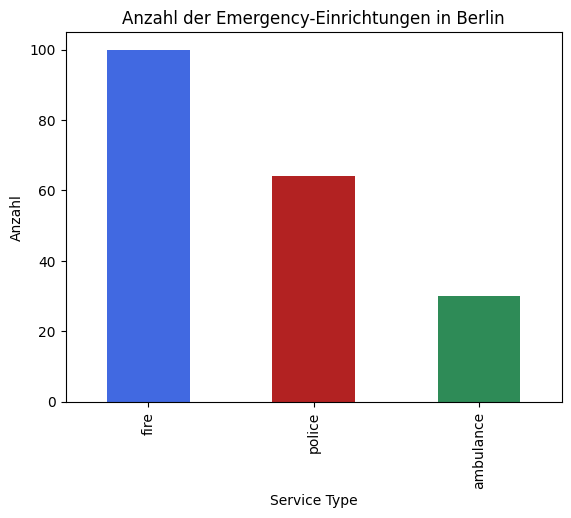

In [309]:
import matplotlib.pyplot as plt

gdf_unified_all['service_type'].value_counts().plot(kind='bar', color=['royalblue', 'firebrick', 'seagreen'])
plt.title('Anzahl der Emergency-Einrichtungen in Berlin')
plt.xlabel('Service Type')
plt.ylabel('Anzahl')
plt.show()

 All service layers concatenated into a single GeoDataFrame (common schema + EPSG:4326).


### Result: Unified Emergency Services Dataset

All emergency service locations (police, fire, ambulance) are now combined into a single GeoDataFrame with:
- identical column structure
- consistent CRS (EPSG:4326)
- point geometries only

This dataset is ready for downstream spatial analysis or export.


### Post-Merge Data Quality Checks

After combining police, fire, and ambulance datasets into one GeoDataFrame, we run a final quality check to ensure:
- geometry is present for all rows
- latitude/longitude are complete


In [310]:
print("Missing geometry:", gdf_unified_all["geometry"].isna().sum())
print("Missing lat/lon:", (gdf_unified_all["latitude"].isna() | gdf_unified_all["longitude"].isna()).sum())


Missing geometry: 0
Missing lat/lon: 0


### OSM-first data integration strategy

OpenStreetMap (OSM) is used as the primary and authoritative data source for all emergency service locations (police, fire, ambulance).

External datasets (Berlin Open Data, Wikidata) are intentionally not integrated at this stage, as OSM provides complete coverage for:
- service locations,
- geometry (lat/lon),
- and core attributes required for the MVP.

Supplementary sources would only be used if OSM was missing:
- verified service locations, or
- critical attributes such as operator, address, or contact information.


### Deduplication across all emergency services

Removing potential duplicate locations based on name similarity and spatial proximity.


In [311]:
before = len(gdf_unified_all)
gdf_unified_all = dedupe_by_name_or_distance(gdf_unified_all, max_dist_m=10.0)
after = len(gdf_unified_all)

print(f"All-services dedupe: {before} -> {after} (removed {before-after})")


All-services dedupe: 194 -> 180 (removed 14)


Global de-duplication applied across all services (name/distance rule).


In [312]:
print("CRS:", gdf_unified_all.crs)
print("Geom types:", gdf_unified_all.geometry.geom_type.value_counts().to_dict())
print("Missing lat:", gdf_unified_all["latitude"].isna().sum())
print("Missing lon:", gdf_unified_all["longitude"].isna().sum())


CRS: EPSG:4326
Geom types: {'Point': 180}
Missing lat: 0
Missing lon: 0


### Result: Final Deduplicated Unified Dataset

We applied a final deduplication step on the merged dataset to remove cross-source duplicates (e.g., highly similar locations within a 10m radius).  
A final sanity check confirms:
- CRS is EPSG:4326
- geometries are Points only
- no missing latitude/longitude values


### Exploratory Validation of the Unified Dataset

Before final export or downstream usage, we inspect the merged and deduplicated dataset to:
- validate column consistency
- review data completeness
- spot-check values across different service types


In [313]:
gdf_unified_all.head()


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
0,limited,Perleberger Straße 61A 10559,<NA>,osm,POINT (13.35364 52.53366),61A,1000029695282,52.533663,13.353639,Polizei Abschnitt 27,NaN,NaN,NaN,10559,police,Perleberger Straße
1,no,Friedrichstraße 219 10969,<NA>,osm,POINT (13.39057 52.50496),219,1000084644753,52.504959,13.390570,Abschnitt 53 Kreuzberg-Nord,NaN,Polizei Berlin,polizei_berlin,10969,police,Friedrichstraße
2,no,None,phone=+49 30 4664 446 701; website=https://www...,osm,POINT (13.34759 52.42769),NaN,1000206102770,52.427692,13.347591,Polizei Abschnitt 46,NaN,Polizei Berlin,polizei_berlin,NaN,police,NaN
3,yes,None,<NA>,osm,POINT (13.22691 52.52802),NaN,1000242769298,52.528017,13.226911,Polizei Abschnitt 22,NaN,NaN,NaN,NaN,police,NaN
4,limited,Rollbergstraße 9 12053,phone=+49 30 4664555700; website=https://www.b...,osm,POINT (13.43476 52.47916),9,1000244118624,52.479156,13.434759,Polizeiabschnitt 55,NaN,NaN,NaN,12053,police,Rollbergstraße


In [314]:
gdf_unified_all.sample(10, random_state=42)


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
19,NaN,None,<NA>,osm,POINT (13.45379 52.49224),NaN,3000014431759,52.492237,13.453791,Kasernengelände Am Treptower Park,NaN,Bundeskriminalamt,bundeskriminalamt,NaN,police,NaN
42,NaN,Lichtenrader Damm 211 12305,phone=+49 30 4664447701; website=https://www.b...,osm,POINT (13.40753 52.39419),211,2000363385011,52.394193,13.407525,Polizei - Abschnitt 47,NaN,Polizei Berlin,polizei_berlin,12305,police,Lichtenrader Damm
153,None,None,None,osm,POINT (13.41548 52.57317),None,2001230192976,52.573174,13.415477,Freiwillige Feuerwehr Pankow,None,NaN,<NA>,None,fire,None
78,None,None,None,osm,POINT (13.40322 52.49553),None,1005764101263,52.495526,13.403222,Freiwillige Feuerwehr Urban,None,NaN,<NA>,None,fire,None
145,None,None,None,osm,POINT (13.43527 52.60755),None,2001036767727,52.607550,13.435272,Feuerwehr Gerätelager,None,Berliner Feuerwehr,<NA>,None,fire,None
15,NaN,Adalbertstraße 3 10999,phone=+49 30 4664553800; website=https://berli...,osm,POINT (13.41838 52.50012),3,1010671508605,52.500122,13.418377,Nebenwache am Kottbusser Tor,NaN,NaN,NaN,10999,police,Adalbertstraße
24,NaN,None,<NA>,osm,POINT (13.24339 52.61827),NaN,2000032551048,52.618272,13.243391,Unknown,NaN,NaN,NaN,NaN,police,NaN
68,None,None,None,osm,POINT (13.2289 52.57075),None,1000332614340,52.570748,13.228902,Freiwillige Feuerwehr Tegelort,None,NaN,<NA>,None,fire,None
113,None,None,None,osm,POINT (13.55004 52.43933),None,2000310079124,52.439330,13.550041,Freiwillige Feuerwehr Adlershof,None,Berliner Feuerwehr,<NA>,None,fire,None
118,None,None,None,osm,POINT (13.53635 52.53581),None,2000369855819,52.535805,13.536352,Feuerwache Marzahn,None,NaN,<NA>,None,fire,None


In [315]:
gdf_unified_all.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 180 entries, 0 to 185
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   accessibility_features  39 non-null     object  
 1   address                 40 non-null     object  
 2   contact_info            39 non-null     object  
 3   data_source             180 non-null    object  
 4   geometry                180 non-null    geometry
 5   house_number            39 non-null     object  
 6   id                      180 non-null    object  
 7   latitude                180 non-null    float64 
 8   longitude               180 non-null    float64 
 9   name                    170 non-null    object  
 10  operating_hours         5 non-null      object  
 11  operator                87 non-null     object  
 12  operator_clean          34 non-null     object  
 13  postal_code             39 non-null     object  
 14  service_type           

In [316]:
gdf_unified_all[gdf_unified_all["service_type"] == "police"].head()


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
0,limited,Perleberger Straße 61A 10559,<NA>,osm,POINT (13.35364 52.53366),61A,1000029695282,52.533663,13.353639,Polizei Abschnitt 27,NaN,NaN,NaN,10559,police,Perleberger Straße
1,no,Friedrichstraße 219 10969,<NA>,osm,POINT (13.39057 52.50496),219,1000084644753,52.504959,13.390570,Abschnitt 53 Kreuzberg-Nord,NaN,Polizei Berlin,polizei_berlin,10969,police,Friedrichstraße
2,no,None,phone=+49 30 4664 446 701; website=https://www...,osm,POINT (13.34759 52.42769),NaN,1000206102770,52.427692,13.347591,Polizei Abschnitt 46,NaN,Polizei Berlin,polizei_berlin,NaN,police,NaN
3,yes,None,<NA>,osm,POINT (13.22691 52.52802),NaN,1000242769298,52.528017,13.226911,Polizei Abschnitt 22,NaN,NaN,NaN,NaN,police,NaN
4,limited,Rollbergstraße 9 12053,phone=+49 30 4664555700; website=https://www.b...,osm,POINT (13.43476 52.47916),9,1000244118624,52.479156,13.434759,Polizeiabschnitt 55,NaN,NaN,NaN,12053,police,Rollbergstraße


### Observation: Service-Specific Data Coverage

A manual inspection confirms that data completeness varies by service type:
- Police stations contain richer metadata (e.g. operator_clean, contact_info)
- Fire and ambulance locations are more sparse, which reflects differences in OSM tagging

This is expected and documented for transparency.


In [317]:
gdf_unified_all[gdf_unified_all["service_type"] == "fire"].head()


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
64,None,None,None,osm,POINT (13.32069 52.48745),None,1000098896966,52.487454,13.320688,Berufsfeuerwache Wilmersdorf,None,Berliner Feuerwehr,<NA>,None,fire,None
65,None,None,None,osm,POINT (13.44455 52.51183),None,1000253618460,52.511829,13.444549,Berufsfeuerwache Friedrichshain,None,Berliner Feuerwehr,<NA>,None,fire,None
66,None,None,None,osm,POINT (13.71616 52.43672),None,1000270905719,52.436717,13.716157,Freiwillige Feuerwehr Wilhelmshagen,None,NaN,<NA>,None,fire,None
67,None,None,None,osm,POINT (13.3892 52.52655),None,1000330880463,52.526553,13.389200,Freiwillige Feuerwehr Mitte,None,Berliner Feuerwehr,<NA>,None,fire,None
68,None,None,None,osm,POINT (13.2289 52.57075),None,1000332614340,52.570748,13.228902,Freiwillige Feuerwehr Tegelort,None,NaN,<NA>,None,fire,None


In [318]:
gdf_unified_all[gdf_unified_all["service_type"] == "ambulance"].head()


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
164,None,None,None,osm,POINT (13.5111 52.63049),None,1001594369164,52.630485,13.511099,Rettungswache Buch,None,Feuerwehr Berlin,<NA>,None,ambulance,None
165,None,None,None,osm,POINT (13.43494 52.60699),None,1002472598641,52.606994,13.434943,NaN,None,NaN,<NA>,None,ambulance,None
166,None,None,None,osm,POINT (13.56692 52.51901),None,1002913900682,52.519008,13.566919,Rettungswache UKB,None,Berliner Feuerwehr,<NA>,None,ambulance,None
167,None,None,None,osm,POINT (13.38789 52.61747),None,1003301254820,52.617467,13.387893,NaN,None,NaN,<NA>,None,ambulance,None
169,None,None,None,osm,POINT (13.31161 52.51859),None,1003607468559,52.518587,13.311613,Malteser Hilfsdienst,None,Malteser Hilfsdienst,<NA>,None,ambulance,None


In [319]:
cols_preview = [
    "id",
    "name",
    "service_type",
    "operator",
    "street",
    "house_number",
    "postal_code",
    "latitude",
    "longitude",
    "data_source",
]

gdf_unified_all[cols_preview].head(15)


,id,name,service_type,operator,street,house_number,postal_code,latitude,longitude,data_source
0,1000029695282,Polizei Abschnitt 27,police,NaN,Perleberger Straße,61A,10559,52.533663,13.353639,osm
1,1000084644753,Abschnitt 53 Kreuzberg-Nord,police,Polizei Berlin,Friedrichstraße,219,10969,52.504959,13.390570,osm
2,1000206102770,Polizei Abschnitt 46,police,Polizei Berlin,NaN,NaN,NaN,52.427692,13.347591,osm
3,1000242769298,Polizei Abschnitt 22,police,NaN,NaN,NaN,NaN,52.528017,13.226911,osm
4,1000244118624,Polizeiabschnitt 55,police,NaN,Rollbergstraße,9,12053,52.479156,13.434759,osm
5,1000261965140,Gemeinsames Terrorismusabwehrzentrum,police,NaN,Am Treptower Park,5-8,12435,52.492215,13.456226,osm
6,1000509897018,Bundespolizei,police,Bundespolizei,NaN,NaN,NaN,52.509321,13.496868,osm
7,1000573418582,Stadionwache,police,NaN,NaN,NaN,NaN,52.513314,13.238435,osm
8,1000614482788,Polizei Berlin – Abschnitt 57,police,Polizei Berlin,Keibelstraße,35,10178,52.524282,13.415696,osm
9,1000659031944,Polizei Berlin Abschnitt 16,police,Polizei Berlin,Storkower Straße,101,10407,52.537977,13.452342,osm


### Missing value overview

Assessing data completeness across attributes to identify sparsely populated fields.


In [320]:
gdf_unified_all.isna().mean().sort_values(ascending=False)


operating_hours           0.972222
operator_clean            0.811111
accessibility_features    0.783333
contact_info              0.783333
house_number              0.783333
postal_code               0.783333
street                    0.783333
address                   0.777778
operator                  0.516667
name                      0.055556
data_source               0.000000
geometry                  0.000000
id                        0.000000
latitude                  0.000000
longitude                 0.000000
service_type              0.000000
dtype: float64

In [321]:
gdf_unified_all.sort_values("service_type").reset_index(drop=True)


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street
0,None,None,None,osm,POINT (13.68958 52.43897),None,2000301286235,52.438968,13.689581,Rettungswache Berlin-Rahnsdorf,None,ASB,<NA>,None,ambulance,None
1,None,None,None,osm,POINT (13.5111 52.63049),None,1001594369164,52.630485,13.511099,Rettungswache Buch,None,Feuerwehr Berlin,<NA>,None,ambulance,None
2,None,None,None,osm,POINT (13.43494 52.60699),None,1002472598641,52.606994,13.434943,NaN,None,NaN,<NA>,None,ambulance,None
3,None,None,None,osm,POINT (13.56692 52.51901),None,1002913900682,52.519008,13.566919,Rettungswache UKB,None,Berliner Feuerwehr,<NA>,None,ambulance,None
4,None,None,None,osm,POINT (13.38789 52.61747),None,1003301254820,52.617467,13.387893,NaN,None,NaN,<NA>,None,ambulance,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,yes,Oudenarder Straße 16 13347,phone=+49 30 4664117701; website=https://www.b...,osm,POINT (13.36063 52.55274),16,2000201855153,52.552742,13.360634,Polizei Abschnitt 17,NaN,NaN,NaN,13347,police,Oudenarder Straße
176,yes,Nöldnerstraße 35 10317,website=https://www.berlin.de/polizei/dienstst...,osm,POINT (13.48452 52.50166),35,2000175568051,52.501657,13.484517,Polizei Abschnitt 34,NaN,Polizei Berlin,polizei_berlin,10317,police,Nöldnerstraße
177,no,Sonnenallee 107 12045,phone=+49 30 4664554700; website=https://www.b...,osm,POINT (13.44079 52.48179),107,2000152197361,52.481788,13.440794,Polizeiabschnitt 54,NaN,NaN,NaN,12045,police,Sonnenallee
178,NaN,Segelfliegerdamm 42 12487,<NA>,osm,POINT (13.50802 52.44348),42,2000143308531,52.443482,13.508017,Polizei Berlin Abschnitt 35,NaN,Polizei Berlin,polizei_berlin,12487,police,Segelfliegerdamm


### Final inspection of unified dataset

The unified emergency services dataset has been cleaned, deduplicated, spatially enriched,
and structurally validated across all service types.


### Final inspection of unified dataset

The unified dataset is sorted and reviewed to ensure structural consistency across service types.


In [322]:
berlin_areas = gpd.read_file("lor_ortsteile.geojson").to_crs(epsg=4326)


In [323]:
print(berlin_areas.crs)
print(berlin_areas.geometry.geom_type.value_counts())
berlin_areas.head()


EPSG:4326
Polygon         95
MultiPolygon     1
Name: count, dtype: int64


,gml_id,spatial_name,spatial_alias,spatial_type,OTEIL,BEZIRK,FLAECHE_HA,geometry
0,re_ortsteil.0101,0101,Mitte,Polygon,Mitte,Mitte,1063.8748,"POLYGON ((13.41649 52.52696, 13.41635 52.52702..."
1,re_ortsteil.0102,0102,Moabit,Polygon,Moabit,Mitte,768.7909,"POLYGON ((13.33884 52.51974, 13.33884 52.51974..."
2,re_ortsteil.0103,0103,Hansaviertel,Polygon,Hansaviertel,Mitte,52.5337,"POLYGON ((13.34322 52.51557, 13.34323 52.51557..."
3,re_ortsteil.0104,0104,Tiergarten,Polygon,Tiergarten,Mitte,516.0672,"POLYGON ((13.36879 52.49878, 13.36891 52.49877..."
4,re_ortsteil.0105,0105,Wedding,Polygon,Wedding,Mitte,919.9112,"POLYGON ((13.34656 52.53879, 13.34664 52.53878..."


### Spatial enrichment with administrative areas (Berlin)

Emergency service locations are spatially joined with Berlin districts and neighborhoods
to enable area-based analysis and aggregation.


In [324]:
# sicherstellen: gleiche CRS
gdf_unified_all = gdf_unified_all.to_crs(epsg=4326)
berlin_areas    = berlin_areas.to_crs(epsg=4326)

# nur die Spalten, die wir brauchen (wie im Beispiel-Notebook)
areas_sel = berlin_areas[["BEZIRK", "OTEIL", "spatial_name", "geometry"]].copy()

# Spatial join (Point innerhalb Polygon)
gdf_joined = gpd.sjoin(
    gdf_unified_all,
    areas_sel,
    how="left",
    predicate="within"
)

gdf_joined.head()


,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street,index_right,BEZIRK,OTEIL,spatial_name
0,limited,Perleberger Straße 61A 10559,<NA>,osm,POINT (13.35364 52.53366),61A,1000029695282,52.533663,13.353639,Polizei Abschnitt 27,NaN,NaN,NaN,10559,police,Perleberger Straße,1,Mitte,Moabit,0102
1,no,Friedrichstraße 219 10969,<NA>,osm,POINT (13.39057 52.50496),219,1000084644753,52.504959,13.390570,Abschnitt 53 Kreuzberg-Nord,NaN,Polizei Berlin,polizei_berlin,10969,police,Friedrichstraße,7,Friedrichshain-Kreuzberg,Kreuzberg,0202
2,no,None,phone=+49 30 4664 446 701; website=https://www...,osm,POINT (13.34759 52.42769),NaN,1000206102770,52.427692,13.347591,Polizei Abschnitt 46,NaN,Polizei Berlin,polizei_berlin,NaN,police,NaN,39,Steglitz-Zehlendorf,Lankwitz,0603
3,yes,None,<NA>,osm,POINT (13.22691 52.52802),NaN,1000242769298,52.528017,13.226911,Polizei Abschnitt 22,NaN,NaN,NaN,NaN,police,NaN,28,Spandau,Spandau,0501
4,limited,Rollbergstraße 9 12053,phone=+49 30 4664555700; website=https://www.b...,osm,POINT (13.43476 52.47916),9,1000244118624,52.479156,13.434759,Polizeiabschnitt 55,NaN,NaN,NaN,12053,police,Rollbergstraße,50,Neukölln,Neukölln,0801


In [325]:
gdf_joined = (
    gdf_joined
    .drop(columns=["index_right"], errors="ignore")
    .rename(columns={
        "BEZIRK": "district",
        "OTEIL": "neighborhood",
        "spatial_name": "neighborhood_id"
    })
)

gdf_joined[["service_type", "name", "district", "neighborhood", "neighborhood_id"]].head(10)


,service_type,name,district,neighborhood,neighborhood_id
0,police,Polizei Abschnitt 27,Mitte,Moabit,0102
1,police,Abschnitt 53 Kreuzberg-Nord,Friedrichshain-Kreuzberg,Kreuzberg,0202
2,police,Polizei Abschnitt 46,Steglitz-Zehlendorf,Lankwitz,0603
3,police,Polizei Abschnitt 22,Spandau,Spandau,0501
4,police,Polizeiabschnitt 55,Neukölln,Neukölln,0801
5,police,Gemeinsames Terrorismusabwehrzentrum,Treptow-Köpenick,Alt-Treptow,0901
6,police,Bundespolizei,Lichtenberg,Rummelsburg,1112
7,police,Stadionwache,Charlottenburg-Wilmersdorf,Westend,0405
8,police,Polizei Berlin – Abschnitt 57,Mitte,Mitte,0101
9,police,Polizei Berlin Abschnitt 16,Pankow,Prenzlauer Berg,0301


 District/neighborhood fields added (district, neighborhood, neighborhood_id).


### Unified emergency services dataset with administrative context

The dataset now includes district and neighborhood information for all police, fire,
and ambulance locations and is ready for analysis or export.


### Standardize district identifiers
Map district names to official district_id codes and validate full coverage.


In [326]:
district_mapping = {
    "Mitte": "11001001",
    "Friedrichshain-Kreuzberg": "11002002",
    "Pankow": "11003003",
    "Charlottenburg-Wilmersdorf": "11004004",
    "Spandau": "11005005",
    "Steglitz-Zehlendorf": "11006006",
    "Tempelhof-Schöneberg": "11007007",
    "Neukölln": "11008008",
    "Treptow-Köpenick": "11009009",
    "Marzahn-Hellersdorf": "11010010",
    "Lichtenberg": "11011011",
    "Reinickendorf": "11012012",
}

gdf_joined["district_id"] = gdf_joined["district"].map(district_mapping).astype("string")


In [327]:
unmapped = gdf_joined.loc[gdf_joined["district"].notna() & gdf_joined["district_id"].isna(), "district"].unique()
print("Unmapped districts:", unmapped)


Unmapped districts: []


In [328]:
print("Missing district:", gdf_joined["district"].isna().sum())
gdf_joined[gdf_joined["district"].isna()][["service_type","name","latitude","longitude"]].head(10)


Missing district: 0


,service_type,name,latitude,longitude


In [329]:
gdf_joined["service_type"].value_counts()

gdf_joined.groupby(["district","service_type"]).size().sort_values(ascending=False).head(20)


district                    service_type
Pankow                      fire            16
Treptow-Köpenick            fire            12
Mitte                       police          12
Reinickendorf               fire            10
Mitte                       fire            10
Charlottenburg-Wilmersdorf  fire             9
Marzahn-Hellersdorf         fire             8
Spandau                     fire             7
Treptow-Köpenick            police           7
Tempelhof-Schöneberg        fire             7
Friedrichshain-Kreuzberg    police           7
Steglitz-Zehlendorf         fire             6
Tempelhof-Schöneberg        police           6
Lichtenberg                 fire             6
Charlottenburg-Wilmersdorf  police           6
Friedrichshain-Kreuzberg    fire             5
Steglitz-Zehlendorf         police           4
Spandau                     police           4
Reinickendorf               police           4
Pankow                      ambulance        4
dtype: int64

district_id mapping validated (no missing/unmapped districts) + distribution checked by service type.


### Final data quality checks after spatial enrichment
Validate row count, geometry integrity, uniqueness of IDs, and geometry types after spatial joins and district mapping.


In [330]:
print("Rows total:", len(gdf_joined))
print("Duplicate IDs:", gdf_joined["id"].duplicated().sum())
print("Missing geometry:", gdf_joined.geometry.isna().sum())
print("Geom types:", gdf_joined.geometry.geom_type.value_counts().to_dict())


Rows total: 180
Duplicate IDs: 0
Missing geometry: 0
Geom types: {'Point': 180}


In [331]:
gdf_joined.isna().mean().sort_values(ascending=False).head(10)


operating_hours           0.972222
operator_clean            0.811111
house_number              0.783333
street                    0.783333
postal_code               0.783333
accessibility_features    0.783333
contact_info              0.783333
address                   0.777778
operator                  0.516667
name                      0.055556
dtype: float64

Optional attributes (e.g. operating_hours, contact_info, accessibility_features) show high missingness, which is expected due to heterogeneous OpenStreetMap coverage across service types.


### Final data quality checks after spatial enrichment
Validate row count, geometry integrity, uniqueness of IDs, and geometry types after spatial joins and district mapping.


### Final unified emergency services schema (MVP)

The unified dataset follows a standardized schema designed for database ingestion.

Mandatory fields:
- id
- service_type
- name
- latitude
- longitude
- geometry (POINT, EPSG:4326)
- district
- district_id
- neighborhood
- neighborhood_id
- data_source

Optional enrichment fields:
- operator
- operator_clean
- address
- street
- house_number
- postal_code
- contact_info
- operating_hours
- accessibility_features

Geometry is currently stored as a GeoDataFrame geometry column and can be exported as WKT for database ingestion if required.


In [332]:
gdf_joined[["service_type","name","street","house_number","postal_code","address","latitude","longitude"]].head()


,service_type,name,street,house_number,postal_code,address,latitude,longitude
0,police,Polizei Abschnitt 27,Perleberger Straße,61A,10559,Perleberger Straße 61A 10559,52.533663,13.353639
1,police,Abschnitt 53 Kreuzberg-Nord,Friedrichstraße,219,10969,Friedrichstraße 219 10969,52.504959,13.390570
2,police,Polizei Abschnitt 46,NaN,NaN,NaN,None,52.427692,13.347591
3,police,Polizei Abschnitt 22,NaN,NaN,NaN,None,52.528017,13.226911
4,police,Polizeiabschnitt 55,Rollbergstraße,9,12053,Rollbergstraße 9 12053,52.479156,13.434759


In [333]:


def build_full_address(row):
    parts = []
    street = row.get("street")
    house = row.get("house_number")
    postal = row.get("postal_code")

    if pd.notna(street):
        if pd.notna(house):
            parts.append(f"{street} {house}".strip())
        else:
            parts.append(str(street).strip())
    if pd.notna(postal):
        parts.append(str(postal).strip())

    return " ".join(parts).strip() if parts else pd.NA

gdf_joined["address"] = gdf_joined.apply(build_full_address, axis=1)


In [334]:
missing_structured = gdf_joined[["street","house_number","postal_code"]].isna().mean()
missing_full = gdf_joined["address"].isna().mean()

print("Missing structured:", missing_structured.to_dict())
print("Missing address:", missing_full)


Missing structured: {'street': 0.7833333333333333, 'house_number': 0.7833333333333333, 'postal_code': 0.7833333333333333}
Missing address: 0.7777777777777778


In [335]:
gdf_joined["service_type"].value_counts()
gdf_joined.groupby("service_type")[["street","house_number","postal_code","address"]].apply(lambda x: x.isna().mean())


,street,house_number,postal_code,address
service_type,,,,
ambulance,1.000000,1.000000,1.000000,1.000
fire,1.000000,1.000000,1.000000,1.000
police,0.390625,0.390625,0.390625,0.375


### Final unified emergency services dataset

At this stage, all emergency service locations (police, fire, ambulance)  
are unified, deduplicated, spatially enriched, and quality-checked.

The following steps focus on address enrichment using reverse geocoding
(Nominatim) for entries with missing address information.


In [336]:
gdf_emergency_services = gdf_joined.copy()


In [337]:
gdf_emergency_services

,accessibility_features,address,contact_info,data_source,geometry,house_number,id,latitude,longitude,name,operating_hours,operator,operator_clean,postal_code,service_type,street,district,neighborhood,neighborhood_id,district_id
0,limited,Perleberger Straße 61A 10559,<NA>,osm,POINT (13.35364 52.53366),61A,1000029695282,52.533663,13.353639,Polizei Abschnitt 27,NaN,NaN,NaN,10559,police,Perleberger Straße,Mitte,Moabit,0102,11001001
1,no,Friedrichstraße 219 10969,<NA>,osm,POINT (13.39057 52.50496),219,1000084644753,52.504959,13.390570,Abschnitt 53 Kreuzberg-Nord,NaN,Polizei Berlin,polizei_berlin,10969,police,Friedrichstraße,Friedrichshain-Kreuzberg,Kreuzberg,0202,11002002
2,no,<NA>,phone=+49 30 4664 446 701; website=https://www...,osm,POINT (13.34759 52.42769),NaN,1000206102770,52.427692,13.347591,Polizei Abschnitt 46,NaN,Polizei Berlin,polizei_berlin,NaN,police,NaN,Steglitz-Zehlendorf,Lankwitz,0603,11006006
3,yes,<NA>,<NA>,osm,POINT (13.22691 52.52802),NaN,1000242769298,52.528017,13.226911,Polizei Abschnitt 22,NaN,NaN,NaN,NaN,police,NaN,Spandau,Spandau,0501,11005005
4,limited,Rollbergstraße 9 12053,phone=+49 30 4664555700; website=https://www.b...,osm,POINT (13.43476 52.47916),9,1000244118624,52.479156,13.434759,Polizeiabschnitt 55,NaN,NaN,NaN,12053,police,Rollbergstraße,Neukölln,Neukölln,0801,11008008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,None,<NA>,None,osm,POINT (13.42923 52.49869),None,2000037549850,52.498690,13.429232,NaN,None,NaN,<NA>,None,ambulance,None,Friedrichshain-Kreuzberg,Kreuzberg,0202,11002002
182,None,<NA>,None,osm,POINT (13.24082 52.53583),None,2000203261713,52.535830,13.240815,Sanitätsdienst Heizkraftwerk Reuter West,None,NaN,<NA>,None,ambulance,None,Spandau,Siemensstadt,0503,11005005
183,None,<NA>,None,osm,POINT (13.57091 52.40559),None,2000221826635,52.405587,13.570906,Rettungswache Bohnsdorf,None,Berliner Feuerwehr,<NA>,None,ambulance,None,Treptow-Köpenick,Bohnsdorf,0908,11009009
184,None,<NA>,None,osm,POINT (13.35065 52.4249),None,2000223290189,52.424904,13.350649,NaN,None,Berliner Feuerwehr,<NA>,None,ambulance,None,Steglitz-Zehlendorf,Lankwitz,0603,11006006


In [338]:
%pip install geopy


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [339]:
import os
print(os.getcwd())


/Users/jarmo/Desktop/Berlin_Map_Project


In [340]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
from time import sleep
from pathlib import Path

# ------------------------------------------------------------
# 0) Choose your final DF (after spatial enrichment)
# ------------------------------------------------------------
# If you already renamed it, skip this:
# gdf_emergency_services = gdf_joined.copy()

# ------------------------------------------------------------
# 1) Init Nominatim (use a descriptive user_agent)
# ------------------------------------------------------------
geolocator = Nominatim(user_agent="webeet_emergency_services_address_enrichment", timeout=10)

# ------------------------------------------------------------
# 2) Helper: safe reverse call with rate limiting + retry
# ------------------------------------------------------------
def safe_reverse(lat, lon, max_retries=3, pause_s=1.1):
    """
    Reverse geocode lat/lon with Nominatim.
    Returns location.raw["address"] dict or None.
    """
    if pd.isna(lat) or pd.isna(lon):
        return None

    for attempt in range(1, max_retries + 1):
        try:
            loc = geolocator.reverse((lat, lon), exactly_one=True, language="de")
            sleep(pause_s)  # IMPORTANT: rate limit
            if loc and "address" in loc.raw:
                return loc.raw["address"]
            return None
        except (GeocoderTimedOut, GeocoderUnavailable):
            sleep(pause_s * attempt)  # backoff
        except Exception:
            # Keep it robust; don't break the pipeline
            sleep(pause_s * attempt)

    return None

# ------------------------------------------------------------
# 3) Extract fields from Nominatim address dict
# ------------------------------------------------------------
def extract_address_fields(addr_dict):
    """
    Map Nominatim address dict -> (street, house_number, postal_code, full_address).
    """
    if not addr_dict:
        return (pd.NA, pd.NA, pd.NA, pd.NA)

    street = addr_dict.get("road") or addr_dict.get("pedestrian") or addr_dict.get("path")
    house = addr_dict.get("house_number")
    postcode = addr_dict.get("postcode")

    # Build a readable full address (Berlin context)
    # Note: do NOT insert your own guessing; only what Nominatim returns.
    parts = []
    if street and house:
        parts.append(f"{street} {house}")
    elif street:
        parts.append(str(street))

    if postcode:
        parts.append(str(postcode))

    # City/locality (sometimes "Berlin", sometimes suburb)
    city = addr_dict.get("city") or addr_dict.get("town") or addr_dict.get("village") or addr_dict.get("municipality")
    if city:
        parts.append(str(city))

    # State/country optional
    # state = addr_dict.get("state")
    # if state: parts.append(str(state))

    full_address = " ".join(parts).strip() if parts else pd.NA

    return (street if street else pd.NA,
            house if house else pd.NA,
            postcode if postcode else pd.NA,
            full_address)

# ------------------------------------------------------------
# 4) Only run for rows with missing address info
# ------------------------------------------------------------
# Choose your "missing condition"
missing_mask = (
    gdf_emergency_services["address"].isna()
    # OR if you prefer structured fields:
    # | gdf_emergency_services["street"].isna()
)

# Optional: limit for testing first (highly recommended)
# idx_to_fill = gdf_emergency_services.loc[missing_mask].index[:10]
idx_to_fill = gdf_emergency_services.loc[missing_mask].index

print(f"Rows needing address enrichment: {len(idx_to_fill)}")

# ------------------------------------------------------------
# 5) Caching to avoid repeated API calls
# ------------------------------------------------------------
# Use a persistent cache file in your repo (small + practical)

cache_path = Path("emergency_services/sources/nominatim_cache.csv")

# Ensure directory exists (safe in all environments)
cache_path.parent.mkdir(parents=True, exist_ok=True)

try:
    cache_df = pd.read_csv(cache_path)

    cache = {
        (float(r["latitude"]), float(r["longitude"])): {
            "street": r["street"] if pd.notna(r["street"]) else pd.NA,
            "house_number": r["house_number"] if pd.notna(r["house_number"]) else pd.NA,
            "postal_code": r["postal_code"] if pd.notna(r["postal_code"]) else pd.NA,
            "address": r["address"] if pd.notna(r["address"]) else pd.NA,
        }
        for _, r in cache_df.iterrows()
    }

    print(f"Loaded cache entries: {len(cache)}")

except FileNotFoundError:
    cache = {}
    print("No cache file found, starting fresh.")

# ------------------------------------------------------------
# 6) Enrichment loop (safe + cached)
# ------------------------------------------------------------
new_cache_rows = []

for i in idx_to_fill:
    lat = gdf_emergency_services.at[i, "latitude"]
    lon = gdf_emergency_services.at[i, "longitude"]

    if pd.isna(lat) or pd.isna(lon):
        continue

    key = (float(lat), float(lon))

    # Use cache if available
    if key in cache:
        enriched = cache[key]
        street, house, postcode, full_addr = enriched["street"], enriched["house_number"], enriched["postal_code"], enriched["address"]
    else:
        addr_dict = safe_reverse(lat, lon, max_retries=3, pause_s=1.1)
        street, house, postcode, full_addr = extract_address_fields(addr_dict)

        cache[key] = {
            "street": street,
            "house_number": house,
            "postal_code": postcode,
            "address": full_addr
        }
        new_cache_rows.append({
            "latitude": lat,
            "longitude": lon,
            "street": street,
            "house_number": house,
            "postal_code": postcode,
            "address": full_addr
        })

    # Fill ONLY if missing (don’t overwrite existing good data)
    if pd.isna(gdf_emergency_services.at[i, "street"]) and pd.notna(street):
        gdf_emergency_services.at[i, "street"] = street

    if pd.isna(gdf_emergency_services.at[i, "house_number"]) and pd.notna(house):
        gdf_emergency_services.at[i, "house_number"] = house

    if pd.isna(gdf_emergency_services.at[i, "postal_code"]) and pd.notna(postcode):
        gdf_emergency_services.at[i, "postal_code"] = postcode

    if pd.isna(gdf_emergency_services.at[i, "address"]) and pd.notna(full_addr):
        gdf_emergency_services.at[i, "address"] = full_addr

# ------------------------------------------------------------
# 7) Save updated cache (append new only)
# ------------------------------------------------------------
if new_cache_rows:
    new_cache_df = pd.DataFrame(new_cache_rows)

    # Merge with existing cache file if it exists
    try:
        old_cache_df = pd.read_csv(cache_path)
        out_cache_df = pd.concat([old_cache_df, new_cache_df], ignore_index=True)
        out_cache_df = out_cache_df.drop_duplicates(subset=["latitude", "longitude"], keep="last")
    except FileNotFoundError:
        out_cache_df = new_cache_df

    out_cache_df.to_csv(cache_path, index=False)
    print(f"Cache updated: +{len(new_cache_rows)} new rows -> saved to {cache_path}")
else:
    print("No new cache rows to write.")

# ------------------------------------------------------------
# 8) Quick QA after enrichment
# ------------------------------------------------------------
qa_cols = ["street", "house_number", "postal_code", "address"]
print("Missing rates after Nominatim:")
print(gdf_emergency_services.groupby("service_type")[qa_cols].apply(lambda x: x.isna().mean()))


Rows needing address enrichment: 140
Loaded cache entries: 141
Cache updated: +33 new rows -> saved to emergency_services/sources/nominatim_cache.csv
Missing rates after Nominatim:
                street  house_number  postal_code  address
service_type                                              
ambulance     0.000000      0.437500     0.000000      0.0
fire          0.000000      0.220000     0.000000      0.0
police        0.015625      0.265625     0.015625      0.0


In [341]:
gdf_emergency_services[["service_type","name","street","house_number","postal_code","address","latitude","longitude"]].head()

,service_type,name,street,house_number,postal_code,address,latitude,longitude
0,police,Polizei Abschnitt 27,Perleberger Straße,61A,10559,Perleberger Straße 61A 10559,52.533663,13.353639
1,police,Abschnitt 53 Kreuzberg-Nord,Friedrichstraße,219,10969,Friedrichstraße 219 10969,52.504959,13.390570
2,police,Polizei Abschnitt 46,Gallwitzallee,NaN,12249,Gallwitzallee 12249 Berlin,52.427692,13.347591
3,police,Polizei Abschnitt 22,Charlottenburger Chaussee,NaN,13597,Charlottenburger Chaussee 13597 Berlin,52.528017,13.226911
4,police,Polizeiabschnitt 55,Rollbergstraße,9,12053,Rollbergstraße 9 12053,52.479156,13.434759


Nominatim enrichment successfully reduced missing full addresses to 0% across all service types.
Structured fields (house_number) remain partially missing, which is expected for large facilities.


In [342]:
gdf_emergency_services[["street","house_number","postal_code","address"]].isna().mean()

street          0.005556
house_number    0.255556
postal_code     0.005556
address         0.000000
dtype: float64

In [343]:
len(gdf_emergency_services)

180

In [344]:
gdf_emergency_services["service_type"].value_counts(dropna=False)


service_type
fire         100
police        64
ambulance     16
Name: count, dtype: int64

In [345]:
(gdf_emergency_services["service_type"] == "hospital").sum()


np.int64(0)

In [346]:
pip install psycopg2-binary


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [347]:
import psycopg2
from psycopg2.extras import execute_values

conn = psycopg2.connect(
    host="localhost",
    port=5433,
    dbname="layereddb",
    user="jarmo_hallberg",
    password="R6mNKYs7UzE3qF6"
)

conn.autocommit = True
cur = conn.cursor()

print("✅ Connected!")


OperationalError: connection to server at "localhost" (::1), port 5433 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5433 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?


In [ ]:
cur.execute("SELECT current_database(), current_schema();")
print(cur.fetchone())


('layereddb', 'public')


In [ ]:
cur.execute("""
SELECT schema_name
FROM information_schema.schemata
ORDER BY schema_name;
""")
schemas = cur.fetchall()
schemas[:20]


[('berlin_labels',),
 ('berlin_mini_dashboard',),
 ('berlin_recommender',),
 ('berlin_source_data',),
 ('berlin_statistics',),
 ('berlin_unified_data',),
 ('dashboard_data',),
 ('information_schema',),
 ('pg_catalog',),
 ('public',),
 ('staging',)]

In [ ]:
df = gdf_emergency_services.copy()

# Falls bei dir hospital irgendwo drin wäre:
df = df[df["service_type"] != "hospital"].copy()

df["service_type"].value_counts()


service_type
fire         100
police        64
ambulance     16
Name: count, dtype: int64

In [ ]:
create_table_sql = """
CREATE TABLE IF NOT EXISTS berlin_source_data.emergency_stations (
    id VARCHAR(20) PRIMARY KEY,
    district_id VARCHAR(20) NOT NULL,
    name VARCHAR(200) NOT NULL DEFAULT 'Unknown',
    station_type VARCHAR(100) NOT NULL,

    country VARCHAR(100),
    city VARCHAR(100),
    street VARCHAR(200),
    housenumber VARCHAR(20),
    postcode VARCHAR(10),
    phone VARCHAR(50),
    email VARCHAR(200),
    website VARCHAR(200),

    latitude DECIMAL(9,6),
    longitude DECIMAL(9,6),
    geometry VARCHAR,

    neighborhood VARCHAR(100),
    district VARCHAR(100),
    neighborhood_id VARCHAR(20),

    operator VARCHAR(200),
    source VARCHAR(100),

    CONSTRAINT emergency_stations_district_fk
        FOREIGN KEY (district_id)
        REFERENCES berlin_source_data.districts(district_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
);
"""
cur.execute(create_table_sql)
print("✅ Table created (or already exists)")


✅ Table created (or already exists)


In [ ]:
cur.execute("TRUNCATE TABLE berlin_source_data.emergency_stations;")
print("✅ Table truncated")


✅ Table truncated


In [ ]:
# Hilfsfunktion: sichere Spalte holen
def safe_col(df, col):
    return df[col] if col in df.columns else None

df_insert = df.copy()

# Spalten umbenennen auf DB-Format
rename_map = {
    "service_type": "station_type",
    "house_number": "housenumber",
    "postal_code": "postcode",
}
df_insert = df_insert.rename(columns=rename_map)

# Pflichtfelder absichern
df_insert["name"] = df_insert["name"].fillna("Unknown")


In [ ]:
import pandas as pd

# geometry -> WKT string (oder None)
if "geometry" in df_insert.columns:
    df_insert["geometry"] = df_insert["geometry"].apply(
        lambda g: g.wkt if g is not None and hasattr(g, "wkt") else (str(g) if pd.notna(g) else None)
    )


/var/folders/l8/7yjy03v10pd_j997bzj8ndq80000gn/T/ipykernel_2197/3891374237.py:5: UserWarning: Geometry column does not contain geometry.
  df_insert["geometry"] = df_insert["geometry"].apply(


In [ ]:
from psycopg2.extras import execute_values

insert_sql = """
INSERT INTO berlin_source_data.emergency_stations (
    id,
    district_id,
    name,
    station_type,
    country,
    city,
    street,
    housenumber,
    postcode,
    phone,
    email,
    website,
    latitude,
    longitude,
    geometry,
    neighborhood,
    district,
    neighborhood_id,
    operator,
    source
)
VALUES %s
"""

rows = []
for _, r in df_insert.iterrows():
    rows.append((
        str(r["id"]) if "id" in df_insert.columns else None,
        str(r["district_id"]) if "district_id" in df_insert.columns else None,
        r.get("name", "Unknown"),
        r.get("station_type", None),
        r.get("country", None),
        r.get("city", None),
        r.get("street", None),
        r.get("housenumber", None),
        r.get("postcode", None),
        r.get("phone", None),
        r.get("email", None),
        r.get("website", None),
        r.get("latitude", None),
        r.get("longitude", None),
        r.get("geometry", None),
        r.get("neighborhood", None),
        r.get("district", None),
        r.get("neighborhood_id", None),
        r.get("operator", None),
        r.get("source", None),
    ))

execute_values(cur, insert_sql, rows)
print(f"✅ Inserted {len(rows)} rows into berlin_source_data.emergency_stations")


✅ Inserted 180 rows into berlin_source_data.emergency_stations


In [ ]:
cur.execute("""
SELECT station_type, COUNT(*)
FROM berlin_source_data.emergency_stations
GROUP BY station_type
ORDER BY COUNT(*) DESC;
""")

cur.fetchall()


[('fire', 100), ('police', 64), ('ambulance', 16)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS duplicate_ids
FROM (
    SELECT id
    FROM berlin_source_data.emergency_stations
    GROUP BY id
    HAVING COUNT(*) > 1
) t;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS duplicate_ids
FROM (
    SELECT id
    FROM berlin_source_data.emergency_stations
    GROUP BY id
    HAVING COUNT(*) > 1
) t;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS out_of_range_coords
FROM berlin_source_data.emergency_stations
WHERE latitude  NOT BETWEEN 52.3 AND 52.7
   OR longitude NOT BETWEEN 13.0 AND 13.8;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS missing_district_id
FROM berlin_source_data.emergency_stations
WHERE district_id IS NULL;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS invalid_district_fk
FROM berlin_source_data.emergency_stations es
LEFT JOIN berlin_source_data.districts d
  ON es.district_id = d.district_id
WHERE d.district_id IS NULL;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS missing_neighborhood_id
FROM berlin_source_data.emergency_stations
WHERE neighborhood_id IS NULL;
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT station_type, COUNT(*) AS cnt
FROM berlin_source_data.emergency_stations
GROUP BY station_type
ORDER BY cnt DESC;
""")
cur.fetchall()


[('fire', 100), ('police', 64), ('ambulance', 16)]

In [ ]:
cur.execute("""
SELECT COUNT(*) AS missing_name
FROM berlin_source_data.emergency_stations
WHERE name IS NULL OR TRIM(name) = '';
""")
cur.fetchall()


[(0,)]

In [ ]:
cur.execute("""
SELECT
  id,
  station_type,
  name,
  district_id,
  district,
  neighborhood_id,
  neighborhood,
  latitude,
  longitude
FROM berlin_source_data.emergency_stations
LIMIT 20;
""")
rows = cur.fetchall()
rows


[('1000029695282',
  'police',
  'Polizei Abschnitt 27',
  '11001001',
  'Mitte',
  '0102',
  'Moabit',
  Decimal('52.533663'),
  Decimal('13.353639')),
 ('1000084644753',
  'police',
  'Abschnitt 53 Kreuzberg-Nord',
  '11002002',
  'Friedrichshain-Kreuzberg',
  '0202',
  'Kreuzberg',
  Decimal('52.504959'),
  Decimal('13.390570')),
 ('1000206102770',
  'police',
  'Polizei Abschnitt 46',
  '11006006',
  'Steglitz-Zehlendorf',
  '0603',
  'Lankwitz',
  Decimal('52.427692'),
  Decimal('13.347591')),
 ('1000242769298',
  'police',
  'Polizei Abschnitt 22',
  '11005005',
  'Spandau',
  '0501',
  'Spandau',
  Decimal('52.528017'),
  Decimal('13.226912')),
 ('1000244118624',
  'police',
  'Polizeiabschnitt 55',
  '11008008',
  'Neukölln',
  '0801',
  'Neukölln',
  Decimal('52.479156'),
  Decimal('13.434759')),
 ('1000261965140',
  'police',
  'Gemeinsames Terrorismusabwehrzentrum',
  '11009009',
  'Treptow-Köpenick',
  '0901',
  'Alt-Treptow',
  Decimal('52.492215'),
  Decimal('13.456226'))

In [ ]:
cur.execute("""
SELECT
  id,
  station_type,
  name,
  district,
  neighborhood,
  latitude,
  longitude
FROM berlin_source_data.emergency_stations
ORDER BY RANDOM()
LIMIT 20;
""")
cur.fetchall()


[('2000048898764',
  'police',
  'Polizeiübungsgelände „Fighting City Ruhleben“',
  'Charlottenburg-Wilmersdorf',
  'Westend',
  Decimal('52.522046'),
  Decimal('13.227222')),
 ('2000547670250',
  'police',
  'Wache am Alexanderplatz',
  'Mitte',
  'Mitte',
  Decimal('52.521442'),
  Decimal('13.413219')),
 ('1000659031944',
  'police',
  'Polizei Berlin Abschnitt 16',
  'Pankow',
  'Prenzlauer Berg',
  Decimal('52.537977'),
  Decimal('13.452342')),
 ('2001299112469',
  'fire',
  'Freiwillige Feuerwehr Rudow (5210)',
  'Neukölln',
  'Rudow',
  Decimal('52.417052'),
  Decimal('13.497242')),
 ('2000306713736',
  'police',
  'Polizei Abschnitt 14',
  'Pankow',
  'Weißensee',
  Decimal('52.557411'),
  Decimal('13.467358')),
 ('2000476997250',
  'fire',
  'Berliner Feuerwehr FW Pankow',
  'Pankow',
  'Pankow',
  Decimal('52.582132'),
  Decimal('13.429327')),
 ('1003607468559',
  'ambulance',
  'Malteser Hilfsdienst',
  'Charlottenburg-Wilmersdorf',
  'Charlottenburg',
  Decimal('52.518587'),

In [ ]:
cur.execute("""
SELECT *
FROM (
  SELECT
    *,
    ROW_NUMBER() OVER (PARTITION BY station_type ORDER BY RANDOM()) AS rn
  FROM berlin_source_data.emergency_stations
) t
WHERE rn <= 5
ORDER BY station_type, rn;
""")
cur.fetchall()


[('2000223290189',
  '11006006',
  'Unknown',
  'ambulance',
  None,
  None,
  'Gallwitzallee',
  '125',
  '12249',
  None,
  None,
  None,
  Decimal('52.424904'),
  Decimal('13.350649'),
  'POINT (13.3506490148815 52.424904052867255)',
  'Lankwitz',
  'Steglitz-Zehlendorf',
  '0603',
  'Berliner Feuerwehr',
  None,
  1),
 ('2000037549850',
  '11002002',
  'Unknown',
  'ambulance',
  None,
  None,
  'Wiener Straße',
  None,
  '10999',
  None,
  None,
  None,
  Decimal('52.498690'),
  Decimal('13.429232'),
  'POINT (13.429232449259331 52.49869031517321)',
  'Kreuzberg',
  'Friedrichshain-Kreuzberg',
  '0202',
  'NaN',
  None,
  2),
 ('1002472598641',
  '11003003',
  'Unknown',
  'ambulance',
  None,
  None,
  'Gravensteinstraße',
  None,
  '13127',
  None,
  None,
  None,
  Decimal('52.606994'),
  Decimal('13.434943'),
  'POINT (13.4349432 52.6069939)',
  'Französisch Buchholz',
  'Pankow',
  '0310',
  'NaN',
  None,
  3),
 ('1012427208983',
  '11001001',
  'Rettungswache Tiergarten Süd

In [ ]:
import pandas as pd

cur.execute("""
SELECT
  station_type,
  name,
  street,
  housenumber,
  postcode,
  city,
  district,
  neighborhood,
  latitude,
  longitude
FROM berlin_source_data.emergency_stations
ORDER BY station_type
LIMIT 25;
""")

df_preview = pd.DataFrame(cur.fetchall(), columns=[desc[0] for desc in cur.description])
df_preview


,station_type,name,street,housenumber,postcode,city,district,neighborhood,latitude,longitude
0,ambulance,Unknown,Gallwitzallee,125,12249,None,Steglitz-Zehlendorf,Lankwitz,52.424904,13.350649
1,ambulance,Unknown,Hauptstraße,None,13159,None,Pankow,Blankenfelde,52.617467,13.387893
2,ambulance,Rettungswache Falkenhagener Feld,Stadtrandstraße,555 - 563,13589,None,Spandau,Falkenhagener Feld,52.564235,13.155519
3,ambulance,Rettungswache Bohnsdorf,Grottewitzstraße,None,12526,None,Treptow-Köpenick,Bohnsdorf,52.405587,13.570906
4,ambulance,Rettungswache Tiergarten Süd,Lützowstraße,24-26,10785,None,Mitte,Tiergarten,52.503618,13.363622
5,ambulance,Malteser Hilfsdienst,Alt-Lietzow,33,10587,None,Charlottenburg-Wilmersdorf,Charlottenburg,52.518587,13.311613
6,ambulance,Rettungswache UKB,Warener Straße,7,12683,None,Marzahn-Hellersdorf,Biesdorf,52.519008,13.566920
7,ambulance,Unknown,Breite Straße,46/47,13187,None,Pankow,Pankow,52.570433,13.414990
8,ambulance,Rettungswache Adlershof,Anna-Seghers-Straße,171b,12489,None,Treptow-Köpenick,Adlershof,52.431841,13.549152
9,ambulance,Sanitätsdienst Heizkraftwerk Reuter West,Großer Spreering,None,13599,None,Spandau,Siemensstadt,52.535830,13.240815
